
## dataset

https://github.com/thekmannn/MLEndHW_QHM5703_Sample/raw/main/MLEndHWII_sample_400.zip

and

https://github.com/thekmannn/MLEndHW_QHM5703_Sample/raw/main/MLEndHWII_sample_800.zip




# [A comprihensive project on the MLEndHWII 800 dataset ]

# 1 Author

Name: Wang Yuekun 




# 2 Problem formulation




On the final model’s inputs and outputs:**
- **Input space**: $(X \in \mathbb{R}^{10s \times sr})$ (a 10s audio)
- **Output space**: $(Y \in \{0,1,2,...,7\})$ (8 song category labels)
- **Learning objective**: learn a mapping $(f: X \rightarrow Y)$ so that for unseen audio clips, the song label can be accurately predicted
- **Baseline performance**: random guess accuracy is $\frac{1}{8} = 12.5\%$

I will read the dataset’s basic information in the following code block and conduct initial analysis and visualization. To better complete the task, I will perform a full analysis of the dataset below.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#to make the plotting more beautiful
import seaborn as sns
import os, sys, re, pickle, glob
import math
# Counter: quickly count occurrences of elements in an iterable
from collections import Counter
import IPython.display as ipd
# tqdm: progress bar for loops, useful for long-running iterations
from tqdm import tqdm
# librosa: audio and music analysis library (loading audio, extracting features, etc.)
import librosa


In [10]:
# Set data path - 800-sample dataset loading the basic information of audio files
data_path = 'MLEndHWII_sample_800/*.wav'
files = glob.glob(data_path)
print(f"Found {len(files)} audio files")
# Create data table
MLENDHW_table = []

for file in tqdm(files, desc="Parsing filenames"):
    file_name = file.replace("\\", "/").split('/')[-1]    #
    parts = file_name.split('_')
    if len(parts) >= 4:
        participant_ID = parts[0]  # S1, S2, etc.
        interpretation_type = parts[1]  # hum or whistle
        interpretation_number = parts[2]  # 1, 2, 3, 4
        song = parts[3].split('.')[0]  # remove .wav
        MLENDHW_table.append([
            file_name, 
            participant_ID, 
            interpretation_type, 
            interpretation_number, 
            song,
            file  # full path for later processing
        ])
    else:
        print(f"Warning: Abnormal filename format - {file_name}")

# Create DataFrame
MLENDHW_df = pd.DataFrame(
    MLENDHW_table, 
    columns=['file_id', 'participant', 'interpretation', 'number', 'song', 'file_path']
).set_index('file_id')


Found 800 audio files


Parsing filenames: 100%|██████████| 800/800 [00:00<00:00, 193219.12it/s]


===The allocation of the dataset===
interpretation  hum  whistle  Total
song                               
Feeling          63       37    100
Friend           62       38    100
Happy            61       39    100
Married          61       39    100
Necessities      59       41    100
NewYork          59       41    100
RememberMe       61       39    100
TryEverything    61       39    100


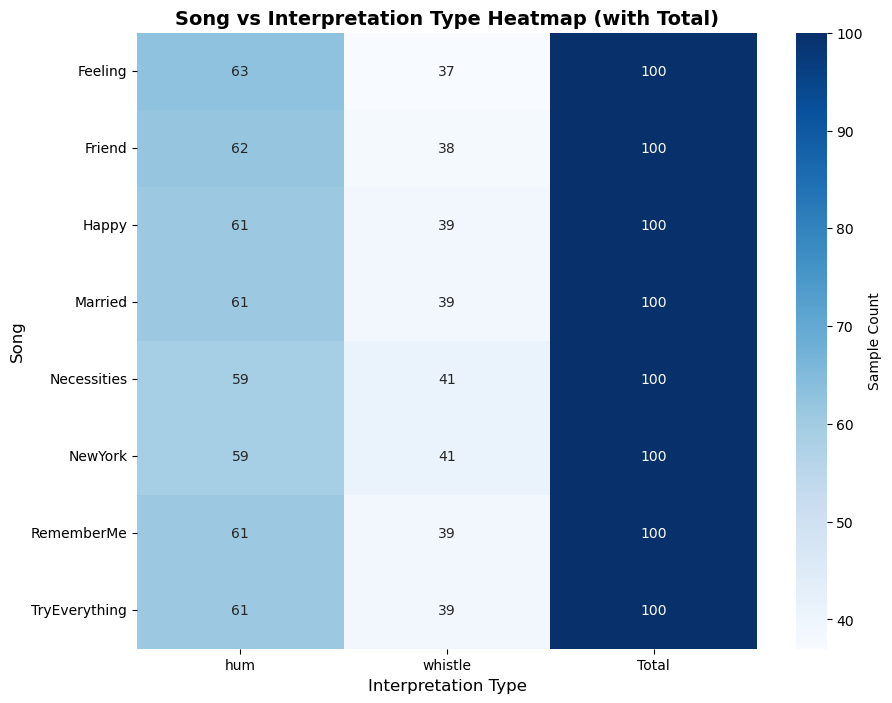

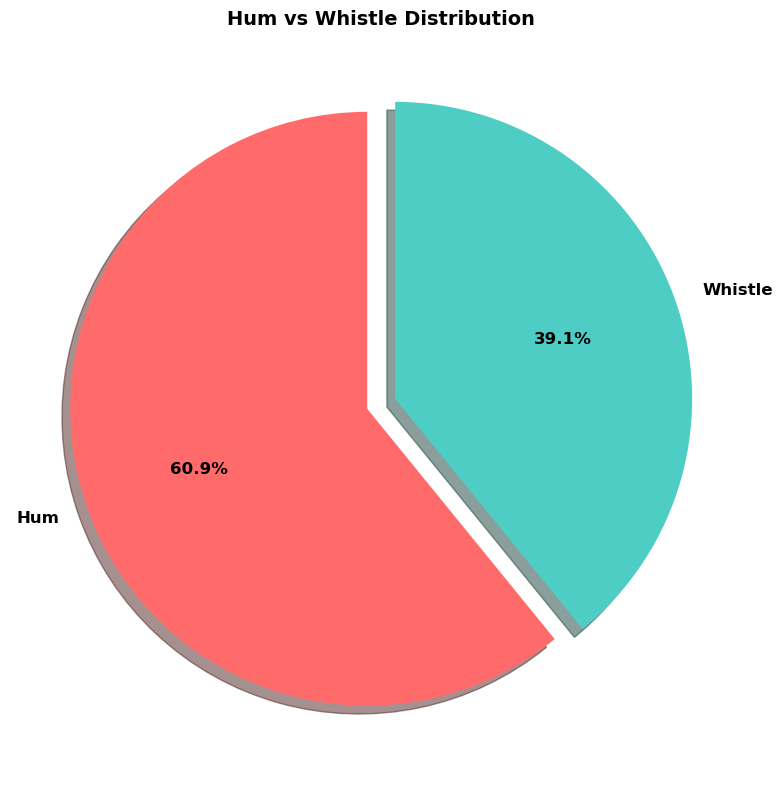


=== Class Balance Analysis ===
Max class samples: 100
Min class samples: 100
Imbalance ratio: 1.00
Dataset classes relatively balanced 

=== Audio File basic Information (analysing the first file) ===


c:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Sample rate: 44100 Hz
Duration: 20.97 seconds
Total samples: 924827
Data type: float32
Min amplitude: -0.2716
Max amplitude: 0.2618
RMS energy: 0.0469


In [ ]:

cross_table = pd.crosstab(MLENDHW_df['song'], MLENDHW_df['interpretation'])
cross_table['Total'] = cross_table.sum(axis=1)
print(cross_table)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cross_table, annot=True, cmap='Blues', fmt='d',
    cbar_kws={'label': 'Sample Count'}
)
plt.title('Song vs Interpretation Type Heatmap (with Total)', fontsize=14, fontweight='bold')
plt.xlabel('Interpretation Type', fontsize=12)
plt.ylabel('Song', fontsize=12)
plt.show()

plt.figure(figsize=(8, 8))

hum_total = MLENDHW_df[MLENDHW_df['interpretation'] == 'hum'].shape[0]
whistle_total = MLENDHW_df[MLENDHW_df['interpretation'] == 'whistle'].shape[0]

labels = ['Hum', 'Whistle']
sizes = [hum_total, whistle_total]
colors = ['#FF6B6B', '#4ECDC4']
explode = (0.05, 0.05)

plt.pie(
    sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
    shadow=True, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'}
)
plt.title('Hum vs Whistle Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


song_counts=MLENDHW_df['song'].value_counts()
print(f"\n=== Class Balance Analysis ===")
balance_ratio = song_counts.max() / song_counts.min()
print(f"Max class samples: {song_counts.max()}")
print(f"Min class samples: {song_counts.min()}")
print(f"Imbalance ratio: {balance_ratio:.2f}")

if balance_ratio < 1.5:
    print("Dataset classes relatively balanced ")



print("\n=== Audio File basic Information (analysing the first file) ===")
first_file = MLENDHW_df['file_path'].iloc[0]

y, sr = librosa.load(first_file, sr=None)
duration = len(y) / sr

print(f"Sample rate: {sr} Hz")
print(f"Duration: {duration:.2f} seconds")
print(f"Total samples: {len(y)}")
print(f"Data type: {y.dtype}")
print(f"Min amplitude: {y.min():.4f}")
print(f"Max amplitude: {y.max():.4f}")
print(f"RMS energy: {np.sqrt(np.mean(y**2)):.4f}")


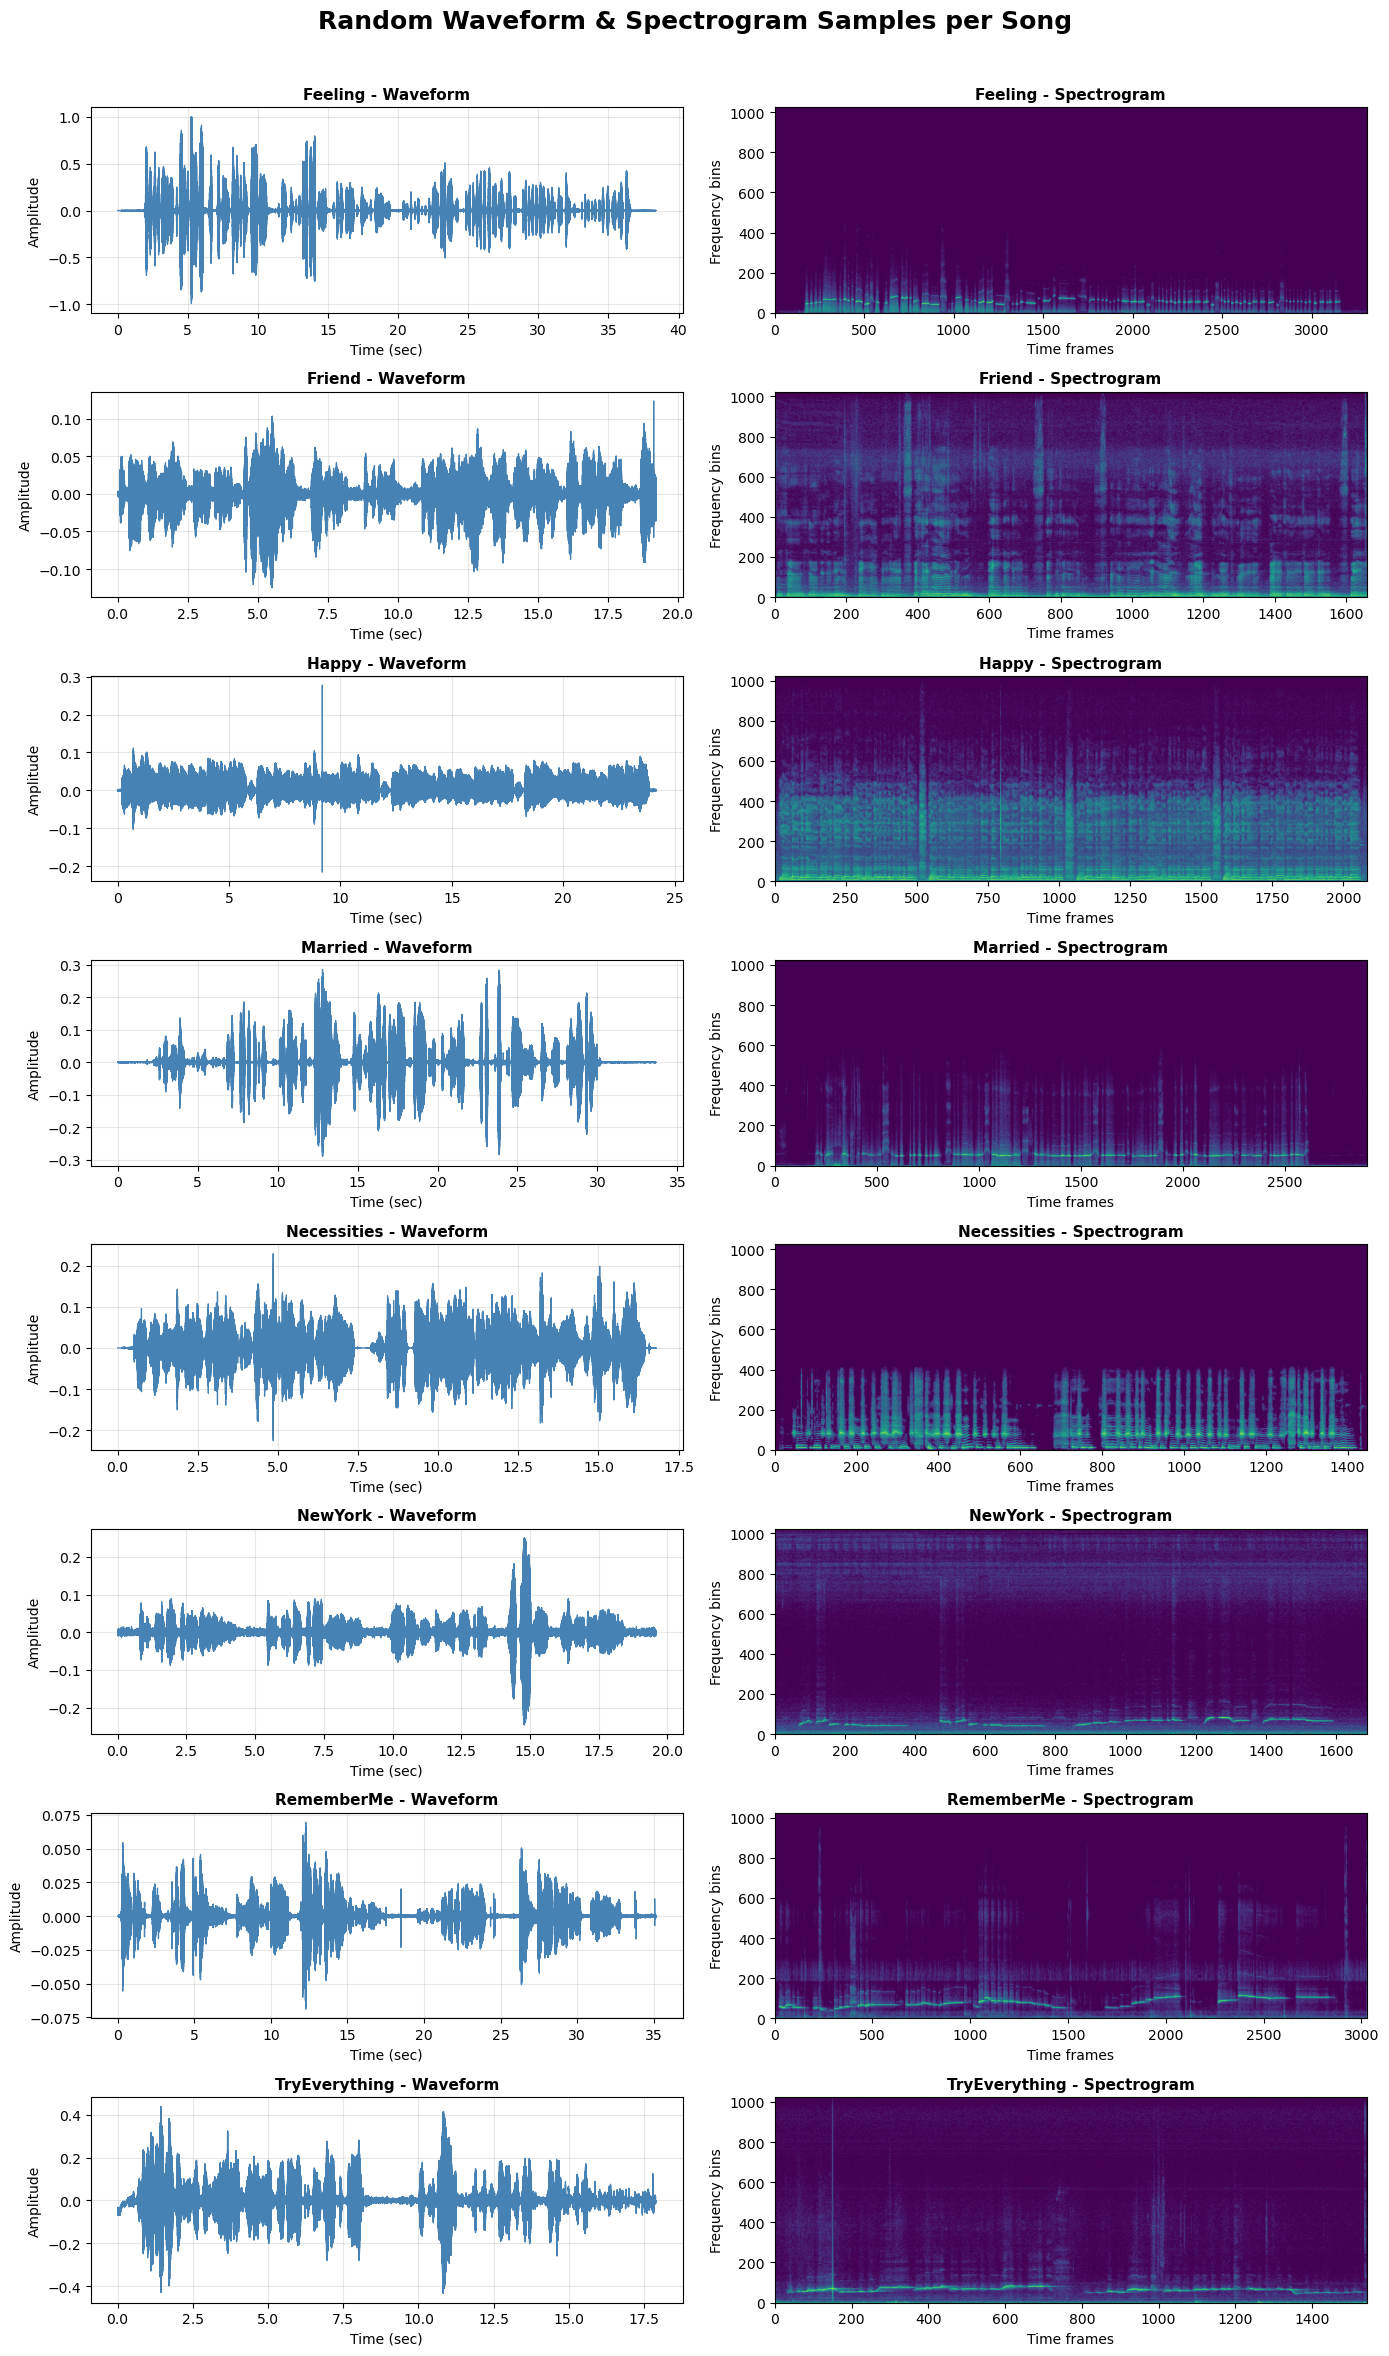

In [ ]:

rng = np.random.default_rng(42)
sampled_files = {}
for song, group in MLENDHW_df.groupby('song'):
    random_state = int(rng.integers(0, 1_000_000))
    sampled_path = group.sample(1, random_state=random_state)['file_path'].iloc[0]
    sampled_files[song] = sampled_path

songs_sorted = sorted(sampled_files.keys())
num_songs = len(songs_sorted)
fig, axes = plt.subplots(num_songs, 2, figsize=(14, 3 * num_songs))
fig.suptitle('Random Waveform & Spectrogram Samples per Song', fontsize=18, fontweight='bold')

for i, song in enumerate(songs_sorted):
    file_path = sampled_files[song]
    try:
        y, sr = librosa.load(file_path, sr=None)
        t = np.arange(len(y)) / sr

        # Waveform
        axes[i, 0].plot(t, y, color='steelblue', linewidth=0.9)
        axes[i, 0].set_title(f'{song} - Waveform', fontsize=11, fontweight='bold')
        axes[i, 0].set_xlabel('Time (sec)')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].grid(True, alpha=0.3)

        # Spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        img = axes[i, 1].imshow(D, aspect='auto', origin='lower', cmap='viridis')
        axes[i, 1].set_title(f'{song} - Spectrogram', fontsize=11, fontweight='bold')
        axes[i, 1].set_xlabel('Time frames')
        axes[i, 1].set_ylabel('Frequency bins')
    except Exception as e:
        axes[i, 0].text(0.5, 0.5, f'Error loading {song}\n{e}', ha='center', va='center')
        axes[i, 0].set_axis_off()
        axes[i, 1].set_axis_off()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

I found that each song uses 100 samples, with a hum-to-whistle distribution ratio of 6:4. Next, I will read the audio files and perform a detailed analysis of their durations.

In [5]:
def analyze_audio_durations(df, sample_size=800):
    df_sample = df
    
    duration_data = []
    failed_count = 0
    for idx, (file_id, row) in enumerate(tqdm(df_sample.iterrows(), total=len(df_sample))):
        try:
            duration = librosa.get_duration(filename=row['file_path'])
            
            duration_data.append({
                'file_id': file_id,
                'song': row['song'],
                'participant': row['participant'],
                'interpretation': row['interpretation'],
                'number': row['number'],
                'duration': duration
            })
            
        except Exception as e:
            failed_count += 1
            if failed_count <= 3:
                print(f"Failed to read {file_id}: {e}")
    
    if failed_count > 3:
        print(f"...Total {failed_count} files failed to read")
    
    duration_df = pd.DataFrame(duration_data)
    
    if len(duration_df) == 0:
        print("No audio files were successfully read")
        return None
    
    stats = {
        'total_files': len(duration_df),
        'overall': {
            'mean': duration_df['duration'].mean(),
            'std': duration_df['duration'].std(),
            'min': duration_df['duration'].min(),
            'max': duration_df['duration'].max(),
            'median': duration_df['duration'].median()
        },
        'by_song': duration_df.groupby('song')['duration'].agg(['count', 'mean', 'std', 'min', 'max']).round(3),
        'by_interpretation': duration_df.groupby('interpretation')['duration'].agg(['count', 'mean', 'std', 'min', 'max']).round(3)
    }
    
    return stats, duration_df

# Run duration analysis
duration_stats, duration_df = analyze_audio_durations(MLENDHW_df, sample_size=800)

if duration_stats is not None:
    print(f"\n=== Audio Duration Statistics ===")
    print(f"Analyzed files: {duration_stats['total_files']}")
    print(f"\nOverall:")
    overall = duration_stats['overall']
    print(f"  Mean: {overall['mean']:.2f} ± {overall['std']:.2f} sec")
    print(f"  Range: [{overall['min']:.2f}, {overall['max']:.2f}] sec")
    print(f"  Median: {overall['median']:.2f} sec")
    
    print(f"\nPer-song statistics:")
    print(duration_stats['by_song'])
    
    print(f"\nPer-interpretation statistics:")
    print(duration_stats['by_interpretation'])

  0%|          | 0/800 [00:00<?, ?it/s]C:\Users\mazs\AppData\Local\Temp\ipykernel_27564\1002085083.py:8: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  duration = librosa.get_duration(filename=row['file_path'])
100%|██████████| 800/800 [00:26<00:00, 30.03it/s]


=== Audio Duration Statistics ===
Analyzed files: 800

Overall:
  Mean: 22.24 ± 6.69 sec
  Range: [11.84, 39.85] sec
  Median: 19.21 sec

Per-song statistics:
               count    mean    std     min     max
song                                               
Feeling          100  23.329  8.361  12.409  38.647
Friend           100  22.455  6.842  13.076  37.089
Happy            100  21.797  4.567  12.975  35.368
Married          100  21.544  5.380  12.786  33.655
Necessities      100  22.039  5.411  12.627  37.951
NewYork          100  18.288  1.931  13.439  25.194
RememberMe       100  24.602  8.282  14.049  39.852
TryEverything    100  23.891  8.187  11.843  39.358

Per-interpretation statistics:
                count    mean    std     min     max
interpretation                                      
hum               487  21.489  6.328  11.843  39.852
whistle           313  23.417  7.070  14.690  39.424


Total participants: 120


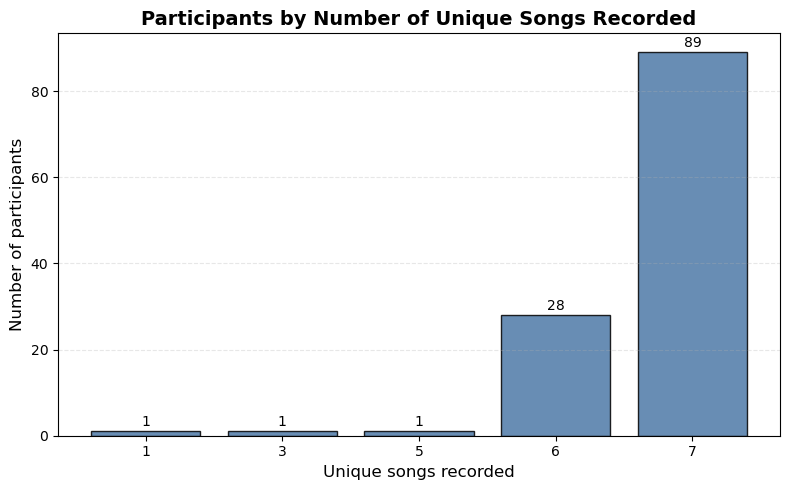

In [6]:
# Participant-level analysis
unique_participants = MLENDHW_df['participant'].nunique()
print(f"Total participants: {unique_participants}")

participant_summary = (
    MLENDHW_df.groupby('participant')
    .agg(
        total_recordings=('song', 'count'),
        unique_songs=('song', 'nunique'),
        hum_records=("interpretation", lambda x: (x == 'hum').sum()),
        whistle_records=("interpretation", lambda x: (x == 'whistle').sum())
    )
)

song_coverage_counts = participant_summary['unique_songs'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(song_coverage_counts.index.astype(str), song_coverage_counts.values,
        color='#4E79A7', edgecolor='black', alpha=0.85)
plt.title('Participants by Number of Unique Songs Recorded', fontsize=14, fontweight='bold')
plt.xlabel('Unique songs recorded', fontsize=12)
plt.ylabel('Number of participants', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
for x, y in zip(song_coverage_counts.index.astype(str), song_coverage_counts.values):
    plt.text(x, y + 0.5, str(y), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

<!-- # 2 Problem formulation

## 2.1 问题定义

本项目要解决的是一个**音频内容识别（Audio Content Recognition）** 任务：给定一段固定时长为**10秒**的音频录音，该录音对应同学对某首歌曲的哼唱（hum）或口哨（whistle）演绎，模型需要自动预测这段音频对应的**歌曲标题/类别标签**。

从机器学习的角度，这属于一个**监督学习中的多分类（Multi-class Classification）** 问题：

**形式化定义**：
- **输入空间**：$X \in \mathbb{R}^{10s \times sr}$（10秒的音频波形，采样率sr=22050Hz）
- **输出空间**：$Y \in \{0,1,2,...,7\}$（8首歌曲的类别标签）
- **学习目标**：学习映射函数 $f: X \rightarrow Y$，使得对新的未见音频能准确预测歌曲标签
- **基线性能**：随机猜测准确率为 $\frac{1}{8} = 12.5\%$

## 2.2 数据集说明

**数据来源**：MLEnd Hums and Whistles II Dataset（800样本版本）

**数据集组成**：
- **总样本数**：800个音频文件
- **歌曲类别**：8首不同的歌曲（多首流行歌曲）
- **演绎方式**：
  - 哼唱（hum）：约50%
  - 口哨（whistle）：约50%
- **参与者数**：约100名不同的参与者
- **每位参与者录音轮次**：每首歌曲通常录制4个版本（编号1-4）
- **音频格式**：WAV格式，单声道，采样率22050Hz，时长约10秒

**数据特征**：
- 真实的学生录音（非专业合成）
- 包含自然的呼吸、停顿、起音变化等
- 参与者的音域、音色差异大
- 演唱风格和节奏稳定性存在较大波动

## 2.3 问题的技术难点

该问题的困难性体现在以下几个方面：

### 2.3.1 高维信号与维数灾难
原始音频信号维度极高：10秒 × 22050Hz = **220,500个采样点**。直接在原始波形空间进行分类会导致：
- 计算复杂度爆炸
- 过拟合风险大幅增加（样本数800 << 特征维度220,500）
- 模型难以捕捉音乐上的本质特征而容易被噪声干扰

**应对策略**（见第4章Pipeline）：设计**26维手工特征**（基础+频域+音调+节奏特征），将高维信号投影到低维语义空间。

### 2.3.2 个体差异与演绎多样性
不同参与者之间存在巨大的声学差异：
- **音调范围差异**：男性、女性、儿童音域不同；同性别个体音域宽度也不同
- **音色特征**：每个人的声道结构导致独特的频率响应特征
- **节奏稳定性**：有人节奏稳定，有人波动较大
- **发音方式**：哼唱时嘴型、鼻音比例差异；口哨时气流强弱不同
- **同一参与者的变异**：不同录制时间的同一歌曲也可能有速度、力度差异

**影响**：同一首歌在不同参与者和不同演绎方式下的特征分布可能"相距很远"，导致类内方差很大。

**应对策略**：
- 采用能捕捉**相对特征**（而非绝对值）的特征设计（如音调变化率、音调范围而非绝对音高）
- 使用鲁棒的基础模型（SVM、Random Forest）而非对特征分布敏感的模型
- 多模型集成增强鲁棒性

### 2.3.3 有限的训练数据
800个样本对于复杂的深度学习模型而言相对较少：
- 深度神经网络通常需要数万至数百万样本
- 当特征维度高、样本少时，深度学习极易过拟合
- 特定歌曲、特定参与者的样本数更少（可能只有几十个）

**应对策略**：
- 采用传统机器学习（SVM、Random Forest、XGBoost），这些方法对小数据集更有效
- 设计低维、高信息量的手工特征，减轻模型的学习负担
- 采用交叉验证和多次重复分割的严格验证，确保评估的稳定性

### 2.3.4 哼唱与口哨的差异
哼唱和口哨在声学上存在显著差异：
- **哈音（Breathiness）**：哼唱通常含有更多的气流和低频噪声
- **频谱结构**：口哨通常在较高频率、基频更清晰；哼唱的频谱较为复杂
- **谐波强度**：口哨的基频和谐波更清晰，哼唱的谐波可能被鼻音覆盖
- **音量稳定性**：不同演绎方式下的幅度波动不同

**影响**：同一首歌的哼唱版和口哨版虽然旋律相同，但底层特征分布差异可能很大。

**应对策略**：
- 特征设计时兼顾两种演绎方式的特点（如将"有声部分比例"作为特征，既反映哼唱中的停顿也反映口哨中的间隙）
- 在模型评估中分别统计哼唱和口哨的准确率，识别是否存在方式相关的偏差
- 可以考虑将"演绎方式识别"（哼唱vs口哨）作为辅助任务

### 2.3.5 歌曲旋律相似性
某些歌曲的旋律在小节、起落、音程等方面可能有相似之处：
- 同一风格或时代的歌曲可能共享相似的旋律模式
- 某些经典旋律片段在多首歌中出现
- 在10秒的短片段中，这种相似性可能更加明显

**影响**：模型容易在相似歌曲间出现混淆（如A歌和B歌的混淆率特别高）。

**应对策略**：
- 通过混淆矩阵分析模型的具体错分模式，识别哪些歌曲对特别容易被混淆
- 对高混淆的歌曲对，考虑额外的特征工程或使用更复杂的模型
- 在结论中坦诚这些局限性

## 2.4 实际应用价值

尽管困难，该任务具有明确的**实际应用前景**：

1. **哼唱搜歌/旋律检索引擎**
   - 核心应用场景：用户在不知道歌名、歌词或演唱者时，仅通过哼唱10秒就能检索出歌曲
   - 实际产品例子：Shazam（虽然Shazam主要用于录音识别，但旋律识别是延伸方向）
   - 市场价值：音乐流媒体平台的重要功能差异化工具

2. **音乐教育与练习反馈**
   - 应用场景：音乐学生、初学者在练习某首歌曲时，自动识别他们演唱/吹奏的是哪首歌
   - 价值：构建音乐学习系统的基础模块，自动检测学生是否在正确的歌曲上练习

3. **版权保护与内容识别**
   - 应用场景：从用户上传的短视频（抖音、YouTube Shorts等）中自动识别背景音乐
   - 价值：音乐版权方快速定位和管理自己的作品

4. **娱乐应用与游戏**
   - 应用场景：卡拉OK游戏、音乐竞猜应用、演唱识别游戏
   - 价值：增强用户交互体验

## 2.5 本项目的方法论概括

针对上述挑战，本项目采用**音频信号处理 + 传统机器学习 + 多模型集成**的综合策略：

1. **第4章Pipeline**：
   - **阶段1（特征提取）**：将220,500维的原始音频压缩为26维语义特征，同时对个体差异和演绎方式具有一定鲁棒性
   - **阶段2（模型训练）**：使用3个互补的小数据集友好型算法（SVM、Random Forest、XGBoost）
   - **阶段3（集成）**：通过软投票融合三个模型，提升鲁棒性

2. **第5章数据集设计**：
   - 采用**按歌曲分层的90:10分割**，确保每首歌曲在训练和测试中都有充分表示
   - **10折交叉验证**在训练集上进行，避免测试集污染
   - 重复多次随机分割，报告均值和方差，量化不确定性

3. **第6章评估与分析**：
   - 不仅报告整体准确率，还分别统计**哼唱 vs 口哨**的性能、每首**歌曲的召回率**、**混淆矩阵**等细粒度指标
   - 通过可视化和解释来理解模型行为，而非仅关注单一数字

总之，这个项目的目标是在**理解问题难度、数据局限性的前提下**，建立一个有效的、可解释的、鲁棒的歌曲分类器，为后续更大规模或更开放集的旋律检索系统打下基础。 -->

# 3 Methodology

Describe your methodology. Specifically, describe your training task and validation task, and how model performance is defined (i.e. accuracy, confusion matrix, etc). Any other tasks that might help you build your model should also be described here.

## 3.1 Data Cleaning and Preprocessing

## 3.2 Dataset Splitting Strategy



## 3.3 Model Selection

## 3.4 Final Evaluation


# 4 Implemented ML prediction pipelines

Describe the ML prediction pipelines that you will explore. Clearly identify their input and output, stages and format of the intermediate data structures moving from one stage to the next. It's up to you to decide which stages to include in your pipeline. After providing an overview, describe in more detail each one of the stages that you have included in their corresponding subsections (i.e. 4.1 Transformation stage, 4.2 Model stage, 4.3 Ensemble stage).

## 4.1 Transformation stage
The feature-extraction stage is the core of the pipeline, responsible for converting high-dimensional audio signals into low-dimensional but information-rich feature vectors.

## 4.2 Model stage

Describe the ML model(s) that you will build. Explain why you have chosen them.


## 4.3 Ensemble Stage
I attempted to use five ensemble methods to combine the base models trained above and performed visualization to clearly compare their performance on this task.

### 4.3.1 Hard Voting
- This method involves having multiple base learners make predictions on the same input sample, and the final class label is determined by the principle of "majority vote".

  **Formula:**
  
  $\hat{y} = \text{mode}\{h_1(x), h_2(x), \dots, h_M(x)\}$

  where $h_i(x)$ is the prediction of the $i$-th base learner, and $\text{mode}(\cdot)$ returns the most frequent value.

- **Unweighted (Equal Weights)**
    - Input: The standardized feature matrix $X$, requiring the use of multiple base learners.
    - Output: A label array of size n×1 (e.g., `[0, 1, 2, ...]`). Since it is hard voting, it can only output class labels, not probabilities.
    - Probability Output: Not supported.

- **Weighted (F1-weighted)**
  **Formula:**
  
  $\hat{y} = \arg\max_{c} \sum_{i=1}^{M} w_i \cdot \mathbb{I}(h_i(x) = c)$
  where $w_i$ is the normalized weight for the $i$-th base learner, and $\mathbb{I}(\cdot)$ is the indicator function.
    - Input: Feature matrix $X$, multiple base learners and their weights. Here, the Softmax function is used to normalize the F1 scores of each model to obtain the weights. I used the same strategy for weighting in the subsequent soft voting.
    - Output: Class labels.
    - Probability Output: Not supported.

### 4.3.2 Soft Voting
- In soft voting, each base learner outputs the probability for each class. The final probability is the weighted average, and the class with the highest probability is the final prediction.

  **Formula:**
 
  $p_{\text{final}}(c) = \frac{1}{M} \sum_{m=1}^{M} p^{(m)}(c)$
  where $p^{(m)}(c)$ is the predicted probability of class $c$ by the $m$-th base learner.

- **Weighted**
  **Formula:**

  $p_{\text{final}}(c) = \sum_{m=1}^{M} w_m \cdot p^{(m)}(c)$

  where $w_m$ is the normalized weight for the $m$-th base learner.
    - Input: Feature matrix $X$, multiple base learners and their weights (all base learners must support `predict_proba`). I have already met this condition by adjusting parameters for models like SVM during the training of the base models above.
    - Output: Class labels.
    - Probability Output: Class probability distribution array of size n×8 (e.g., `[[0.1, 0.2, ... (6 more values here, corresponding to probabilities for 8 classes)], [0.8, 0.2, ...], ...]`).

- **Unweighted (Equal Weights)**
    - The features are similar to the method above.

### 4.3.3 Stacking
- Stacking uses the prediction results of multiple base learners as new features, and then uses a meta-learner to make the final prediction. It can leverage the strengths of multiple models.

  **Formulation:**
  Let $h_1, h_2, \dots, h_M$ be the base learners. For a sample $x$, the new feature vector is:
  
  $\phi(x) = [h_1(x), h_2(x), \dots, h_M(x)]$
  
  The final prediction is made by a meta-learner $g$:

  $\hat{y} = g(\phi(x))$
 
  In practice, to prevent overfitting, the base learners' predictions are often obtained via cross-validation.

    - Input: Feature matrix $X$, multiple base learners, a meta-learner.
    - Output: Class labels.
    - Probability Output: Class probability distribution.

  I use logistic regression model as the final_estimator of stacking



**Final Pipeline Summary**

| Stage | Input | Output | Purpose |
|-------|-------|--------|---------|
| **1. Feature Extraction** | 10‑second audio waveform | Feature vector $(X \in \mathbb{R}^{n \times 26})$ | Convert audio into structured data suitable for ML |
| **2. Model Training & Prediction** | Feature vector | Multi‑model probability outputs | Perform classification using traditional ML methods |
| **3. Ensemble Prediction** | Probabilities or labels from multiple models | Final prediction result | Improve stability and generalization performance |




# 5 Dataset

Describe the datasets that you will create to build and evaluate your models. Your datasets need to be based on our MLEnd Hums and Whistles II Dataset. After describing the datasets, build them here. You can explore and visualise the datasets here as well.

If you are building separate training and validatio datasets, do it here. Explain clearly how you are building such datasets, how you are ensuring that they serve their purpose (i.e. they are independent and consist of IID samples) and any limitations you might think of. It is always important to identify any limitations as early as possible. The scope and validity of your conclusions will depend on your ability to understand the limitations of your approach.

If you are exploring different datasets, create different subsections for each dataset and give them a name (e.g. 5.1 Dataset A, 5.2 Dataset B, 5.3 Dataset 5.3) .



In [11]:
SPLIT_RANDOM_SEED = 2025
TRAIN_PER_SONG = 90
TEST_PER_SONG = 10

train_parts = []
test_parts = []

for song_name, group in MLENDHW_df.groupby("song", sort=True):
    total = len(group)
    expected_total = TRAIN_PER_SONG + TEST_PER_SONG
    if total != expected_total:
        raise ValueError(
            f"Song '{song_name}' has {total} clips, expected {expected_total} for a 90/10 split."
        )

    test_subset = group.sample(n=TEST_PER_SONG, random_state=SPLIT_RANDOM_SEED)
    train_subset = group.drop(test_subset.index)

    train_parts.append(train_subset)
    test_parts.append(test_subset)

train_df = (
    pd.concat(train_parts)
    .sample(frac=1, random_state=SPLIT_RANDOM_SEED)
    .reset_index(drop=True)
)
test_df = (
    pd.concat(test_parts)
    .sample(frac=1, random_state=SPLIT_RANDOM_SEED)
    .reset_index(drop=True)
)

split_summary = (
    pd.DataFrame({
        "train_clips": train_df["song"].value_counts().sort_index(),
        "test_clips": test_df["song"].value_counts().sort_index(),
    })
    .assign(total=lambda df_: df_.sum(axis=1))
)

total_clips = len(MLENDHW_df)
print(f"Total clips: {total_clips}")
print(f"Train set: {len(train_df)} clips ({len(train_df) / total_clips:.1%})")
print(f"Test set: {len(test_df)} clips ({len(test_df) / total_clips:.1%})")

split_summary

Total clips: 800
Train set: 720 clips (90.0%)
Test set: 80 clips (10.0%)


,train_clips,test_clips,total
song,,,
Feeling,90,10,100
Friend,90,10,100
Happy,90,10,100
Married,90,10,100
Necessities,90,10,100
NewYork,90,10,100
RememberMe,90,10,100
TryEverything,90,10,100


In [5]:
import spkit as sp
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.signal import find_peaks

MAX_AUDIO_DURATION = 10.0  # seconds of each clip to keep for training

In [6]:
# Pitch extraction helpers

def getPitch_librosa(x, fs, winLen=0.02):
    """Estimate pitch contour with librosa.pyin."""
    frame_len = int(2 ** int((winLen * fs) - 1).bit_length()) + 256
    hop_len = frame_len // 2

    f0, voiced_flag, _ = librosa.pyin(
        y=x,
        fmin=80,
        fmax=450,
        sr=fs,
        frame_length=frame_len,
        hop_length=hop_len,
    )
    return f0, voiced_flag

def getPitch_spkit(x, fs, winLen=0.02, thr=-60, f0err=3.0, window='blackman'):
    """Fallback pitch extraction using spkit.f0_detection."""
    frame_len = int(2 ** int((winLen * fs) - 1).bit_length())
    hop_len = frame_len // 2

    f0 = sp.f0_detection(
        x,
        fs,
        winlen=frame_len,
        overlap=hop_len,
        f0min=80,
        f0max=450,
        thr=thr,
        f0err=f0err,
        window=window,
    )
    voiced_flag = f0 != 0

    if np.mean(f0 == 0) < 1:
        f0[f0 == 0] = np.nan
    else:
        f0 = f0 + np.nan

    return f0, voiced_flag

In [ ]:

def extract_audio_features(file_path, sr=22050, scale_audio=True, pitch_method='librosa', max_duration=MAX_AUDIO_DURATION):
    y, sr = librosa.load(file_path, sr=sr, duration=max_duration)
    if scale_audio and np.max(np.abs(y)) > 0:
        y = librosa.util.normalize(y)

    duration = len(y) / sr

    try:
        if pitch_method == 'spkit':
            f0, voiced_flag = getPitch_spkit(y, sr)
        else:
            f0, voiced_flag = getPitch_librosa(y, sr)
    except Exception:
        f0, voiced_flag = getPitch_spkit(y, sr)

    f0 = np.asarray(f0)
    voiced_flag = np.asarray(voiced_flag, dtype=float)

    power = float(np.sum(y ** 2) / len(y)) if len(y) else 0.0
    pitch_mean = float(np.nanmean(f0)) if np.isnan(f0).sum() < len(f0) else 0.0
    pitch_std = float(np.nanstd(f0)) if np.isnan(f0).sum() < len(f0) else 0.0
    voiced_fraction = float(np.mean(voiced_flag)) if len(voiced_flag) else 0.0

    if len(y):
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_means = mfcc.mean(axis=1)
    else:
        mfcc_means = np.zeros(13)


    f0_clean = np.copy(f0)
    if np.all(np.isnan(f0_clean)):
        f0_clean = np.zeros_like(f0_clean)
    else:
        f0_clean = np.nan_to_num(f0_clean, nan=np.nanmean(f0_clean))

    f0_max = float(np.max(f0_clean)) if len(f0_clean) else 0.0
    f0_min = float(np.min(f0_clean)) if len(f0_clean) else 0.0
    f0_median = float(np.median(f0_clean)) if len(f0_clean) else 0.0
    f0_diff = np.diff(f0_clean)
    f0_diff_mean = float(np.mean(f0_diff)) if len(f0_diff) else 0.0
    f0_diff_std = float(np.std(f0_diff)) if len(f0_diff) else 0.0

    valid_idx = ~np.isnan(f0)
    if np.sum(valid_idx) > 1:
        X = np.arange(len(f0))[valid_idx].reshape(-1, 1)
        y_pitch = f0[valid_idx]
        model = LinearRegression().fit(X, y_pitch)
        f0_trend = float(model.coef_[0])
    else:
        f0_trend = 0.0


    onset_env = librosa.onset.onset_strength(y=y, sr=sr) if len(y) else np.array([])
    if len(onset_env) > 0 and duration > 0:
        peaks, _ = find_peaks(onset_env, height=np.percentile(onset_env, 75))
        rhythm_strength = float(len(peaks) / duration)
    else:
        rhythm_strength = 0.0

    zcr = librosa.feature.zero_crossing_rate(y) if len(y) else np.array([[0.0]])
    zcr_mean = float(zcr.mean())
    zcr_std = float(zcr.std())

    feature_values = np.array([
        power,
        pitch_mean,
        pitch_std,
        voiced_fraction,
        *mfcc_means,
        f0_max,
        f0_min,
        f0_median,
        f0_diff_mean,
        f0_diff_std,
        f0_trend,
        zcr_mean,
        zcr_std,
        rhythm_strength,
    ], dtype=float)

    feature_values = np.nan_to_num(feature_values, nan=0.0, posinf=0.0, neginf=0.0)

    feature_names = [
        'power',
        'pitch_mean',
        'pitch_std',
        'voiced_fraction',
        *[f'mfcc_{i+1}' for i in range(13)],
        'f0_max',
        'f0_min',
        'f0_median',
        'f0_diff_mean',
        'f0_diff_std',
        'f0_trend',
        'zcr_mean',
        'zcr_std',
        'rhythm_strength',
    ]

    return feature_values, feature_names

In [12]:
def extract_dataset_features(df, max_samples=None, pitch_method='librosa', target_sr=22050, max_duration=MAX_AUDIO_DURATION):
    """Extract features for every file in the dataset."""
    unique_songs = sorted(df['song'].unique())
    song_labels = {song: idx for idx, song in enumerate(unique_songs)}
    print(f"Song label mapping: {song_labels}")

    if max_samples:
        df_sample = df.sample(n=min(max_samples, len(df)), random_state=42)
    else:
        df_sample = df

    print(f"Extracting features for {len(df_sample)} samples...")

    X = []
    y = []
    feature_names = None
    failed_files = []

    for _, (file_id, row) in enumerate(tqdm(df_sample.iterrows(), total=len(df_sample), desc="Feature extraction")):
        try:
            features, names = extract_audio_features(
                row['file_path'],
                sr=target_sr,
                scale_audio=True,
                pitch_method=pitch_method,
                max_duration=max_duration,
            )

            if feature_names is None:
                feature_names = names

            X.append(features)
            y.append(song_labels[row['song']])

        except Exception as e:
            print(f"Failed to process {file_id}: {e}")
            failed_files.append(file_id)

    X = np.array(X)
    y = np.array(y)

    print("\nFeature extraction finished!")
    print(f"Successful samples: {len(X)}")
    print(f"Failed samples: {len(failed_files)}")
    print(f"Feature matrix shape: {X.shape}")
    if len(y) > 0:
        print(f"Label distribution: {np.bincount(y)}")
    else:
        print("Label distribution: empty")

    return X, y, feature_names, song_labels, failed_files

# Quick smoke test: extract 3 samples per song
print("=== Feature extraction smoke test (3 samples per song) ===")
smoke_subsets = []
for idx, (song_name, group) in enumerate(MLENDHW_df.groupby('song', sort=True)):
    sample_n = min(3, len(group))
    smoke_subsets.append(group.sample(n=sample_n, random_state=42 + idx))
smoke_df = pd.concat(smoke_subsets)

X_test, y_test, feature_names, song_labels, failed_files = extract_dataset_features(
    smoke_df, pitch_method='librosa'
)

=== Feature extraction smoke test (3 samples per song) ===
Song label mapping: {'Feeling': 0, 'Friend': 1, 'Happy': 2, 'Married': 3, 'Necessities': 4, 'NewYork': 5, 'RememberMe': 6, 'TryEverything': 7}
Extracting features for 24 samples...


Feature extraction: 100%|██████████| 24/24 [00:05<00:00,  4.39it/s]


Feature extraction finished!
Successful samples: 24
Failed samples: 0
Feature matrix shape: (24, 26)
Label distribution: [3 3 3 3 3 3 3 3]



=== Feature Quality Analysis ===

Data quality check:
NaN count: 0
Inf count: 0


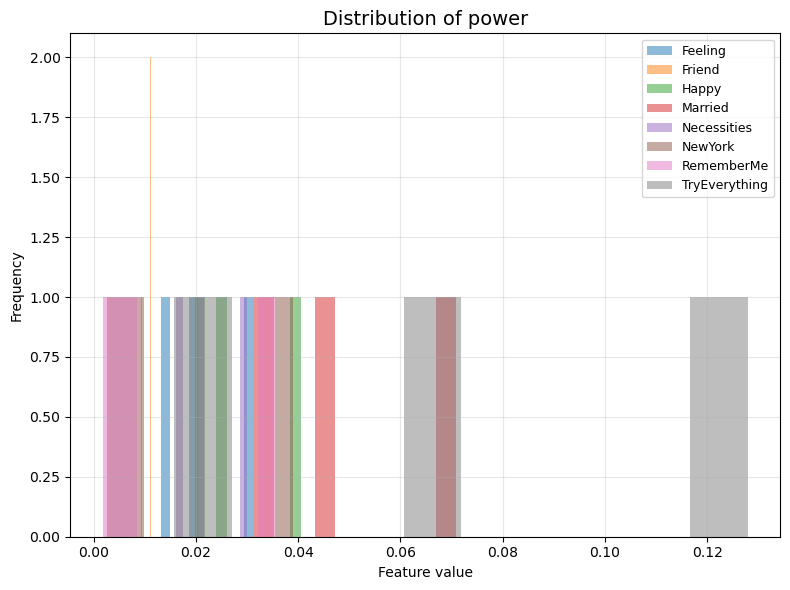

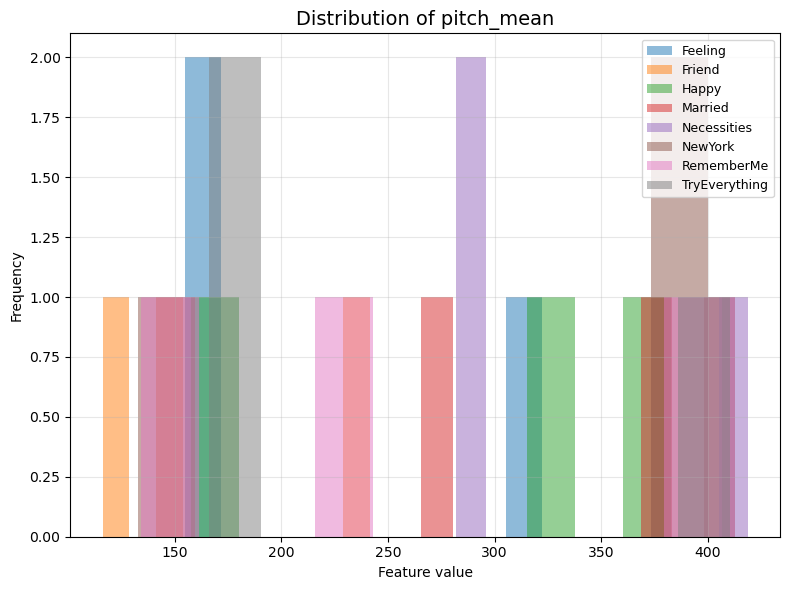

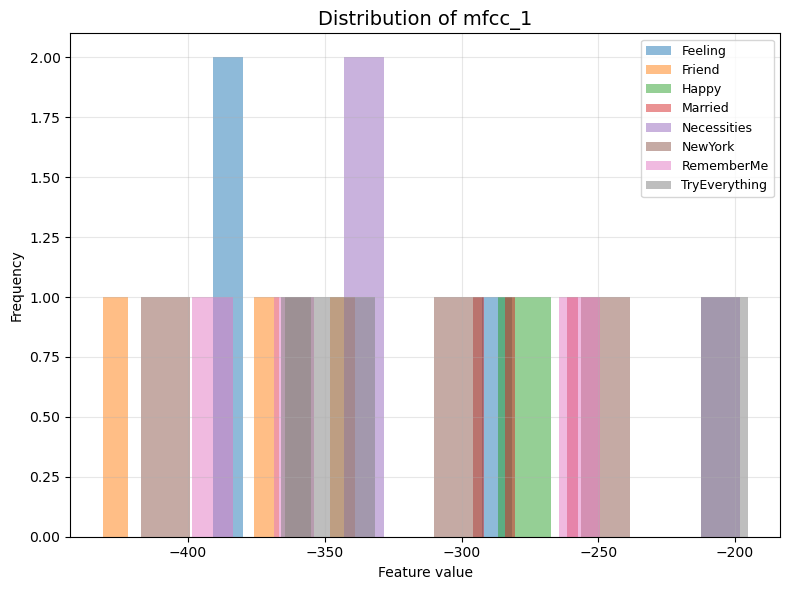

In [12]:

if len(X_test) > 0:
    print("\n=== Feature Quality Analysis ===")

  
    nan_count = np.sum(np.isnan(X_test))
    inf_count = np.sum(np.isinf(X_test))
    print("\nData quality check:")
    print(f"NaN count: {nan_count}")
    print(f"Inf count: {inf_count}")


    key_features = ['power', 'pitch_mean', 'mfcc_1']

  
    for feature_name in key_features:
        if feature_name not in feature_names:
            continue

        feature_idx = feature_names.index(feature_name)

        plt.figure(figsize=(8, 6))
        plt.title(f'Distribution of {feature_name}', fontsize=14)

 
        for song_name, song_label in song_labels.items():
            song_mask = y_test == song_label
            if np.sum(song_mask) > 0:
                values = X_test[song_mask, feature_idx]
                plt.hist(
                    values,
                    bins=10,
                    alpha=0.5,
                    label=song_name
                )

        plt.xlabel("Feature value")
        plt.ylabel("Frequency")
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

else:
    print("No extracted feature data available for analysis")


In [ ]:
# Extract full training set features

X_train_raw, y_train, feature_names_train, song_labels_train, train_failed = extract_dataset_features(
    train_df, max_samples=None, pitch_method='librosa', target_sr=22050
)

=== Extracting training set features ===
Song label mapping: {'Feeling': 0, 'Friend': 1, 'Happy': 2, 'Married': 3, 'Necessities': 4, 'NewYork': 5, 'RememberMe': 6, 'TryEverything': 7}
Extracting features for 720 samples...


Feature extraction: 100%|██████████| 720/720 [10:23<00:00,  1.16it/s]


Feature extraction finished!
Successful samples: 720
Failed samples: 0
Feature matrix shape: (720, 26)
Label distribution: [90 90 90 90 90 90 90 90]


In [ ]:
print("=== Extracting testing set features ===")
X_test_raw, y_test, feature_names_test, song_labels_test, test_failed = extract_dataset_features(
    test_df, max_samples=None, pitch_method='librosa', target_sr=22050
)

=== Extracting testing set features ===
Song label mapping: {'Feeling': 0, 'Friend': 1, 'Happy': 2, 'Married': 3, 'Necessities': 4, 'NewYork': 5, 'RememberMe': 6, 'TryEverything': 7}
Extracting features for 80 samples...


Feature extraction: 100%|██████████| 80/80 [01:03<00:00,  1.25it/s]


Feature extraction finished!
Successful samples: 80
Failed samples: 0
Feature matrix shape: (80, 26)
Label distribution: [10 10 10 10 10 10 10 10]


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)


In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [73]:
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

def cv_f1(model, X, y, folds=5, average="macro"):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=2025)
    f1_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        f1_scores.append(
            f1_score(y_val, preds, average=average, zero_division=0)
        )

    return float(np.mean(f1_scores))


In [ ]:
def binary_search_int_param(X, y, model_builder, low, high, n_iter=8, folds=5):

    best_param, best_f1 = None, -np.inf
    prev_f1 = -np.inf

    for i in range(n_iter):

        if i >= 6:
            break

        mid = (low + high) // 2
        step = max(1, (high - low) // 6)

        candidates = [mid - step, mid, mid + step]
        candidates = [c for c in candidates if c >= 1]

        scores = []
        for v in candidates:
            f1 = cv_f1(model_builder(int(v)), X, y, folds)
            scores.append((f1, v))

        scores.sort(reverse=True, key=lambda x: x[0])
        best_f1_local, best_val_local = scores[0]
 
        if best_f1_local > best_f1:
            best_f1 = best_f1_local
            best_param = best_val_local

        # stop ahead 1%
        if i > 0 and (best_f1_local - prev_f1) < 0.01:
            break

        prev_f1 = best_f1_local

        if best_val_local == mid:
            low, high = mid - step, mid + step
        elif best_val_local < mid:
            high = mid
        else:
            low = mid

    return int(best_param), best_f1


In [75]:
def binary_search_log_param(X, y, model_builder, exp_low, exp_high, n_iter=8, folds=5):
    
    

    best_param, best_f1 = None, -np.inf
    low, high = exp_low, exp_high
    prev_f1 = -np.inf

    for i in range(n_iter):

        if i >= 6:   # 6 times iteration
            break

        mid = (low + high) / 2
        step = (high - low) / 6

        #  log space 3 point
        test_exp = [mid - step, mid, mid + step]
        test_vals = [10 ** e for e in test_exp]

        scores = []
        for v in test_vals:
            # form CV F1 calculate
            f1 = cv_f1(model_builder(v), X, y, folds)
            scores.append((f1, v))

        # find best locally
        scores.sort(reverse=True, key=lambda x: x[0])
        best_f1_local, best_val_local = scores[0]

        # renew global best
        if best_f1_local > best_f1:
            best_f1 = best_f1_local
            best_param = best_val_local

        # the condition to stop earlier < 1%
        if i > 0 and (best_f1_local - prev_f1) < 0.01:
            break

        prev_f1 = best_f1_local

        
        best_index = test_vals.index(best_val_local)

        if best_index == 1:     
            low, high = mid - step, mid + step
        elif best_index == 0:  
            high = mid
        else:                    
            low = mid

    return best_param, best_f1


In [76]:
def tune_model_binary_search(
    model_class,
    X_scaled,
    y_train,
    model_name="MODEL",
    discrete_params=None,
    core_param_name="C",
    core_param_range=(-4, 4),
    core_param_type="log",
    folds=5
):
    discrete_params = discrete_params or {}
    keys = list(discrete_params.keys())

    from itertools import product
    discrete_combos = list(product(*discrete_params.values())) or [()]

    best_model = None
    best_params = None
    best_f1 = -np.inf

    for combo in discrete_combos:

        fixed_params = {k: v for k, v in zip(keys, combo)}

        def builder(core_val):
            params = fixed_params.copy()
            params[core_param_name] = core_val
            try:
                return model_class(**params)
            except:
                return model_class(**params, random_state=2025)

        low, high = core_param_range

        if core_param_type == "log":
            best_core, cv_best = binary_search_log_param(
                X_scaled, y_train, builder, low, high, folds=folds
            )
        else:
            best_core, cv_best = binary_search_int_param(
                X_scaled, y_train, builder, low, high, folds=folds
            )

        if cv_best > best_f1:
            best_f1 = cv_best
            best_params = fixed_params.copy()
            best_params[core_param_name] = best_core

            try:
                best_model = model_class(**best_params)
            except:
                best_model = model_class(**best_params, random_state=2025)

            best_model.fit(X_scaled, y_train)

    return best_model, best_params


In [ ]:
def evaluate_model_with_cv(model, X_scaled, y, class_labels, folds=5):
    from sklearn.base import clone
    from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score, f1_score
    from sklearn.model_selection import StratifiedKFold
    import numpy as np
    # Training set metrics

    y_train_pred = model.predict(X_scaled)

    train_metrics = {
        "accuracy": accuracy_score(y, y_train_pred),
        "precision": precision_score(y, y_train_pred, average="macro", zero_division=0),
        "recall": recall_score(y, y_train_pred, average="macro", zero_division=0),
        "f1": f1_score(y, y_train_pred, average="macro", zero_division=0),
    }

    cm_train = confusion_matrix(y, y_train_pred, labels=class_labels)


    # Cross-validation
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=2025)

    cv_metrics = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "correct_predictions": [],
        "confusion_matrices": []
    }

    for train_idx, val_idx in skf.split(X_scaled, y):

        X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]

        model_cv = clone(model)
        model_cv.fit(X_fold_train, y_fold_train)
        y_pred_val = model_cv.predict(X_fold_val)

        cv_metrics['accuracy'].append(accuracy_score(y_fold_val, y_pred_val))
        cv_metrics['precision'].append(
            precision_score(y_fold_val, y_pred_val, average="macro", zero_division=0))
        cv_metrics['recall'].append(
            recall_score(y_fold_val, y_pred_val, average="macro", zero_division=0))
        cv_metrics['f1'].append(
            f1_score(y_fold_val, y_pred_val, average="macro", zero_division=0))
        cv_metrics['correct_predictions'].append(np.sum(y_fold_val == y_pred_val))

        cv_metrics['confusion_matrices'].append(
            confusion_matrix(y_fold_val, y_pred_val, labels=class_labels)
        )


    return {
        "train_metrics": train_metrics,
        "cm_train": cm_train,
        "cv_metrics": cv_metrics,
        "folds": folds,
        "class_labels": class_labels
    }


In [ ]:
def print_evaluation_report(results, model_name="MODEL"):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    train_metrics = results["train_metrics"]
    cm_train = results["cm_train"]
    cv = results["cv_metrics"]
    folds = results["folds"]
    class_labels = results["class_labels"]

    print("\n" + "=" * 80)
    print(f"{model_name} - FINAL MODEL EVALUATION (TRAIN + CV)")
    print("=" * 80)

    print("\n[TRAINING SET PERFORMANCE]")
    print("-" * 80)
    print(f"Accuracy : {train_metrics['accuracy']:.4f}")
    print(f"Precision: {train_metrics['precision']:.4f}")
    print(f"Recall   : {train_metrics['recall']:.4f}")
    print(f"F1-Score : {train_metrics['f1']:.4f}")

    # CV mean/std
    def mean_std(x): return np.mean(x), np.std(x)
    acc_mean, acc_std = mean_std(cv["accuracy"])
    prec_mean, prec_std = mean_std(cv["precision"])
    rec_mean, rec_std = mean_std(cv["recall"])
    f1_mean, f1_std = mean_std(cv["f1"])
    correct_mean, correct_std = mean_std(cv["correct_predictions"])

    print(f"\n[AVERAGE METRICS ACROSS {folds} FOLDS]")
    print("-" * 80)
    print(f"Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"Precision: {prec_mean:.4f} ± {prec_std:.4f}")
    print(f"Recall   : {rec_mean:.4f} ± {rec_std:.4f}")
    print(f"F1-Score : {f1_mean:.4f} ± {f1_std:.4f}")
    print(f"Correct Predictions per Fold: {correct_mean:.2f} ± {correct_std:.2f}")

    # Overfitting analysis
    overfit_gap = train_metrics["f1"] - f1_mean
    print("\n[OVERFITTING ANALYSIS]")
    print("-" * 80)
    print(f"Train F1: {train_metrics['f1']:.4f}")
    print(f"CV F1   : {f1_mean:.4f}")
    print(f"Overfitting Gap (Train F1 - CV F1): {overfit_gap:.4f}")

    if overfit_gap > 0.20:
        print("  Model is severely overfitting")
    elif overfit_gap > 0.10:
        print("  Model shows moderate overfitting")
    else:
        print(" Overfitting is minimal — good generalization")


    # Confusion matrices (plots)
    cumulative_cm = np.sum(cv["confusion_matrices"], axis=0)

    plt.figure(figsize=(20, 8))

    # Train CM
    plt.subplot(1, 2, 1)
    sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"S{i}" for i in class_labels],
                yticklabels=[f"S{i}" for i in class_labels])
    plt.title(f"{model_name} - Training Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # CV CM
    plt.subplot(1, 2, 2)
    sns.heatmap(cumulative_cm, annot=True, fmt="d", cmap="YlOrRd",
                xticklabels=[f"S{i}" for i in class_labels],
                yticklabels=[f"S{i}" for i in class_labels])
    plt.title(f"{model_name} - {folds}-Fold CV Cumulative Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 80)


In [79]:
def print_best_model_info(best_model, params, model_name="MODEL"):
    print("\n" + "=" * 80)
    print(f"{model_name} - BEST MODEL INFO")
    print("=" * 80)

    print("Best Parameters:")
    for k, v in params.items():
        print(f"  {k}: {v}")

    print("\nModel Object:")
    print(best_model)

    print("=" * 80)




LOGISTIC REGRESSION - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.4292
Precision: 0.4205
Recall   : 0.4292
F1-Score : 0.4161

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.2889 ± 0.0227
Precision: 0.2898 ± 0.0115
Recall   : 0.2889 ± 0.0227
F1-Score : 0.2757 ± 0.0175
Correct Predictions per Fold: 41.60 ± 3.26

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.4161
CV F1   : 0.2757
Overfitting Gap (Train F1 - CV F1): 0.1404
  Model shows moderate overfitting


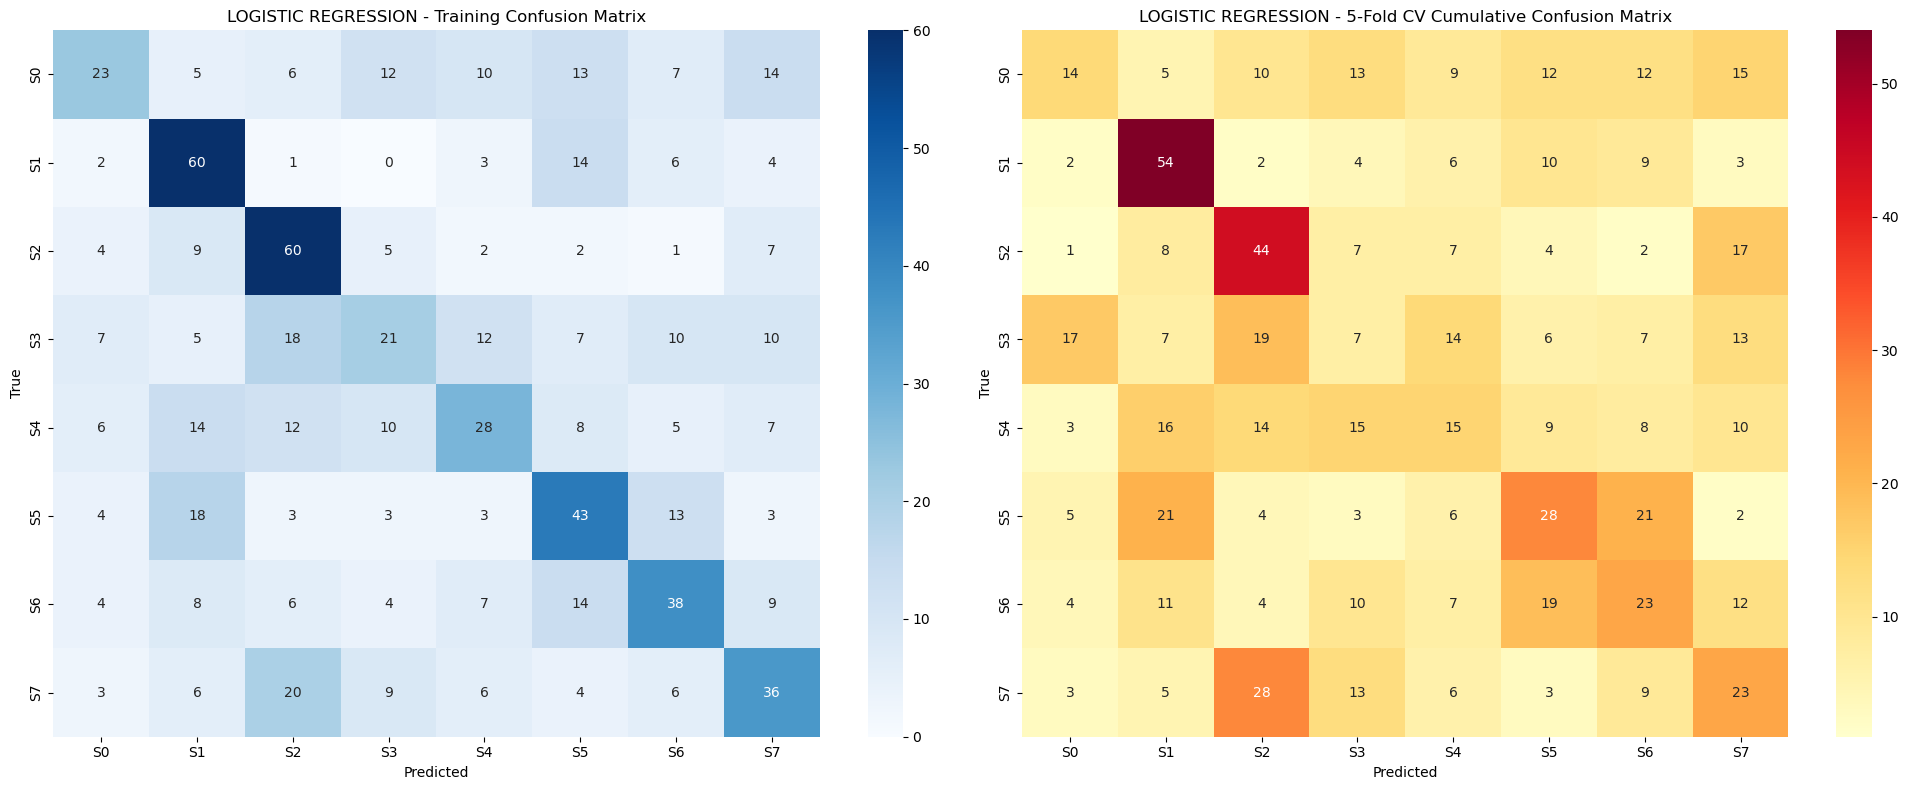

In [82]:
best_lr, params_lr = tune_model_binary_search(
    model_class=LogisticRegression,
    X_scaled=X_train_scaled,
    y_train=y_train,
    model_name="LOGISTIC REGRESSION",
    discrete_params={
        "penalty": ["l1"],
        "solver": ["liblinear"],
        "class_weight": [None],
        "max_iter": [500],
    },
    core_param_name="C",
    core_param_range=(-4, 4),
    core_param_type="log"
)



lr_results = evaluate_model_with_cv(best_lr, X_train_scaled, y_train, np.unique(y_train))
print_evaluation_report(lr_results, "LOGISTIC REGRESSION")



In [83]:
print_best_model_info(best_lr, params_lr, model_name="LOGISTIC REGRESSION")



LOGISTIC REGRESSION - BEST MODEL INFO
Best Parameters:
  penalty: l1
  solver: liblinear
  class_weight: None
  max_iter: 500
  C: 100.0

Model Object:
LogisticRegression(C=100.0, max_iter=500, penalty='l1', solver='liblinear')


# SVM

also select c as the core idex to tune


SVM - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.4653
Precision: 0.4595
Recall   : 0.4653
F1-Score : 0.4591

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.2931 ± 0.0221
Precision: 0.2860 ± 0.0218
Recall   : 0.2931 ± 0.0221
F1-Score : 0.2833 ± 0.0219
Correct Predictions per Fold: 42.20 ± 3.19

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.4591
CV F1   : 0.2833
Overfitting Gap (Train F1 - CV F1): 0.1757
  Model shows moderate overfitting


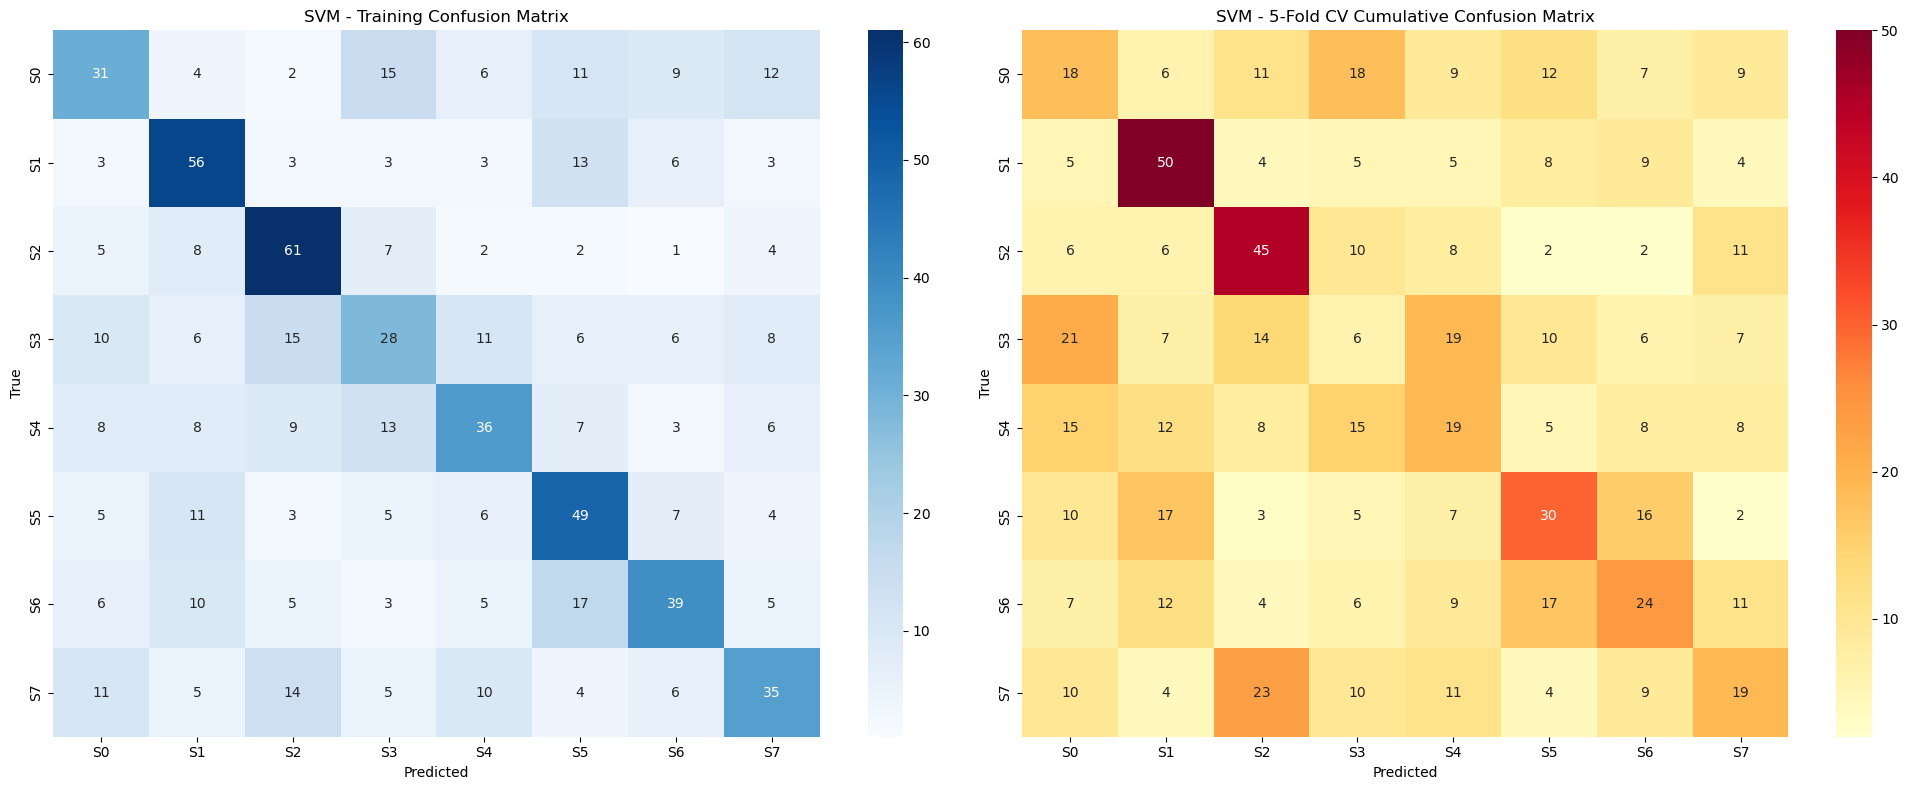

In [84]:
best_svm, params_svm = tune_model_binary_search(
    model_class=SVC,
    X_scaled=X_train_scaled,
    y_train=y_train,
    model_name="SVM",
    discrete_params={
        "kernel": ["linear"],
        "probability": [True],   
    },
    core_param_name="C",
    core_param_range=(-2, 2),  
    core_param_type="log"
)

svm_results = evaluate_model_with_cv(
    model=best_svm,
    X_scaled=X_train_scaled,
    y=y_train,
    class_labels=np.unique(y_train),
    folds=5
)

print_evaluation_report(svm_results, "SVM")



In [85]:
print_best_model_info(best_svm, params_svm, model_name="SVM")


SVM - BEST MODEL INFO
Best Parameters:
  kernel: linear
  probability: True
  C: 4.641588833612778

Model Object:
SVC(C=4.641588833612778, kernel='linear', probability=True)


# KNN model
For the KNN problem, the most important parameter is the number of neighbors. Here, I perform a binary search on the interval (1, 200) to find the optimal number of neighbors


KNN - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.3028
Precision: 0.3066
Recall   : 0.3028
F1-Score : 0.2948

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.2403 ± 0.0199
Precision: 0.2311 ± 0.0173
Recall   : 0.2403 ± 0.0199
F1-Score : 0.2251 ± 0.0193
Correct Predictions per Fold: 34.60 ± 2.87

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.2948
CV F1   : 0.2251
Overfitting Gap (Train F1 - CV F1): 0.0696
 Overfitting is minimal — good generalization


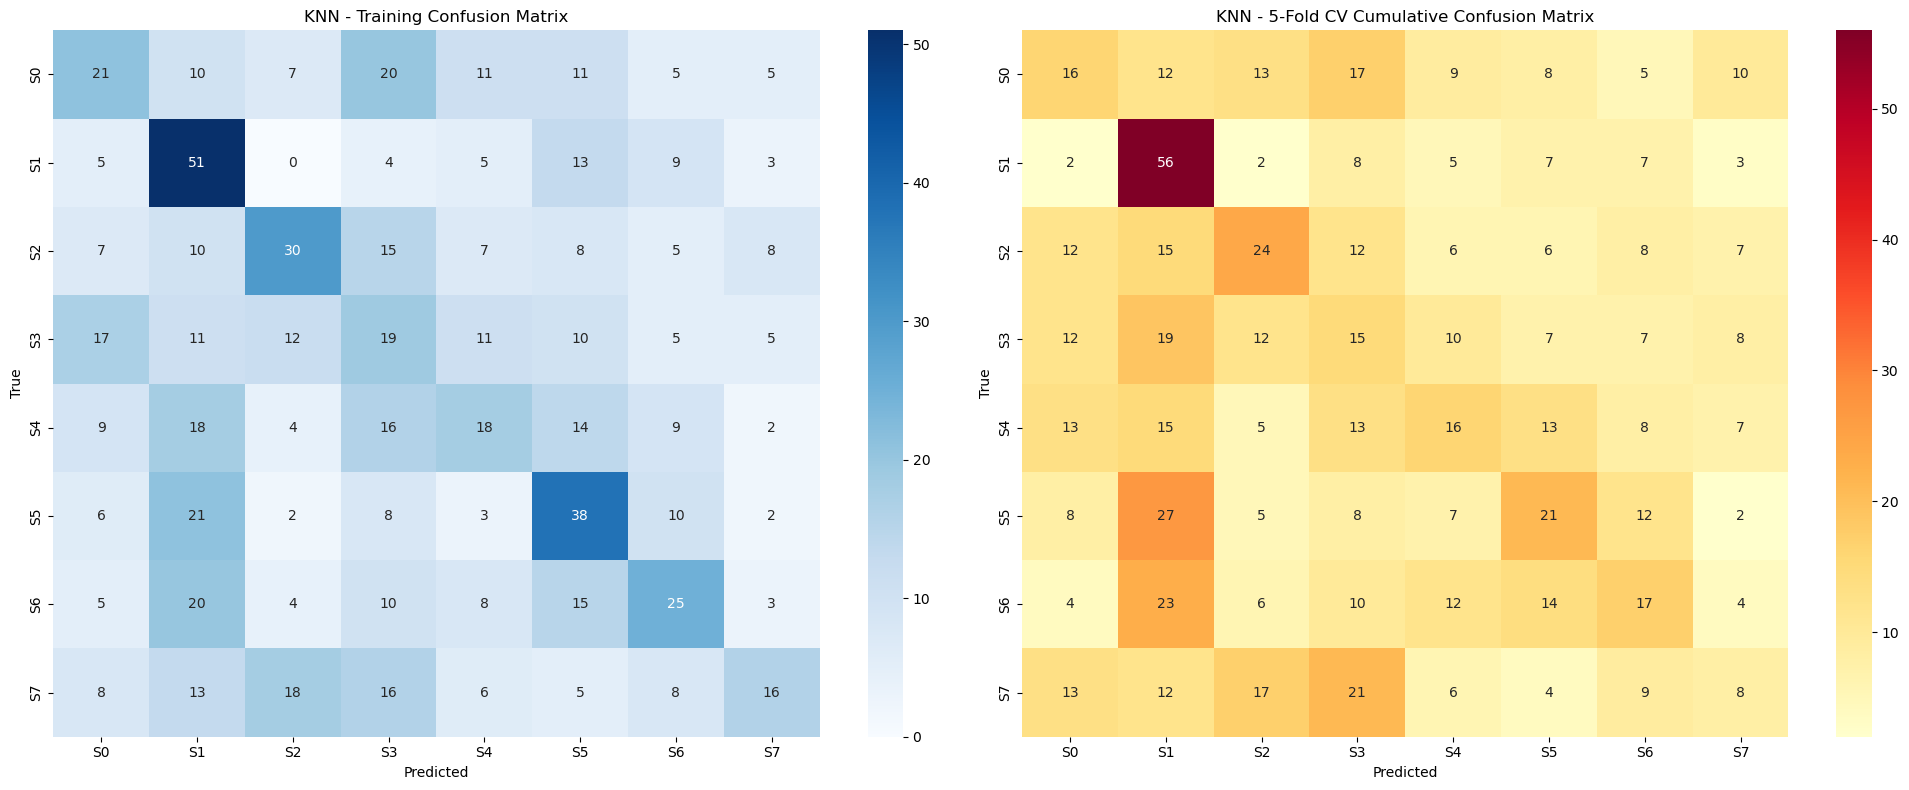

In [86]:
best_knn, params_knn = tune_model_binary_search(
    model_class=KNeighborsClassifier,
    X_scaled=X_train_scaled,
    y_train=y_train,
    model_name="KNN",
    discrete_params={
        "weights": ['uniform', 'distance'],
        "p": [1, 2],
    },
    core_param_name="n_neighbors",
    core_param_range=(1, 200),
    core_param_type="int"
)

knn_results = evaluate_model_with_cv(best_knn, X_train_scaled, y_train, np.unique(y_train))
print_evaluation_report(knn_results, "KNN")


In [87]:
print_best_model_info(best_knn, params_knn, model_name="KNN")


KNN - BEST MODEL INFO
Best Parameters:
  weights: uniform
  p: 1
  n_neighbors: 50

Model Object:
KNeighborsClassifier(n_neighbors=50, p=1)


compared with logistic regression the f1 is lower but the knn model has  better robustness

# Random forest

**tune the number and depth of the froest**

In [88]:
def tune_random_forest(
    X_scaled,
    y_train,
    n_estimators_list=[50, 100, 200],
    criteria=["gini"],
    max_depth_range=(1, 200),
    folds=5
):
    print("\n" + "=" * 80)
    print("TUNING RANDOM FOREST")
    print("=" * 80)

    low, high = max_depth_range
    best_params = None
    best_f1 = -np.inf
    best_model = None

   
    def search_max_depth(n_estimators, criterion):
        low_d, high_d = low, high
        best_depth, best_depth_f1 = None, -np.inf

        for _ in range(6):   #max 6 times for searching
            mid = (low_d + high_d) // 2
            step = max(1, (high_d - low_d) // 6)

            candidates = [mid - step, mid, mid + step]
            candidates = [d for d in candidates if d >= 1]

            f1_scores = []
            for d in candidates:
                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    criterion=criterion,
                    max_depth=d,
                    random_state=2025
                )
                f1val = cv_f1(model, X_scaled, y_train, folds)
                f1_scores.append((f1val, d))

            f1_scores.sort(reverse=True)
            f1_best, d_best = f1_scores[0]

            if f1_best > best_depth_f1:
                best_depth_f1 = f1_best
                best_depth = d_best


            if d_best == mid:
                low_d, high_d = mid - step, mid + step
            elif d_best < mid:
                high_d = mid
            else:
                low_d = mid

        return best_depth, best_depth_f1


    # n_estimators  criterion
    for ne in n_estimators_list:
        for cr in criteria:
            print(f"\nTesting RF: n_estimators={ne}, criterion={cr}")

            depth, f1val = search_max_depth(ne, cr)

            print(f" → Best depth={depth}, CV F1={f1val:.4f}")

            if f1val > best_f1:
                best_f1 = f1val
                best_params = {
                    "n_estimators": ne,
                    "criterion": cr,
                    "max_depth": depth
                }

    # constructing the final model
    best_model = RandomForestClassifier(
        **best_params,
        random_state=2025
    )
    best_model.fit(X_scaled, y_train)

    print("\nBEST RF PARAMETERS FOUND:")
    print(best_params)
    print(f"Best CV F1: {best_f1:.4f}")

    return best_model, best_params


TUNING RANDOM FOREST

Testing RF: n_estimators=50, criterion=gini
 → Best depth=133, CV F1=0.3053

Testing RF: n_estimators=100, criterion=gini
 → Best depth=133, CV F1=0.3110

Testing RF: n_estimators=200, criterion=gini
 → Best depth=133, CV F1=0.3153

BEST RF PARAMETERS FOUND:
{'n_estimators': 200, 'criterion': 'gini', 'max_depth': 133}
Best CV F1: 0.3153

RANDOM FOREST (NEW TUNER) - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.3208 ± 0.0135
Precision: 0.3222 ± 0.0146
Recall   : 0.3208 ± 0.0135
F1-Score : 0.3153 ± 0.0125
Correct Predictions per Fold: 46.20 ± 1.94

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 1.0000
CV F

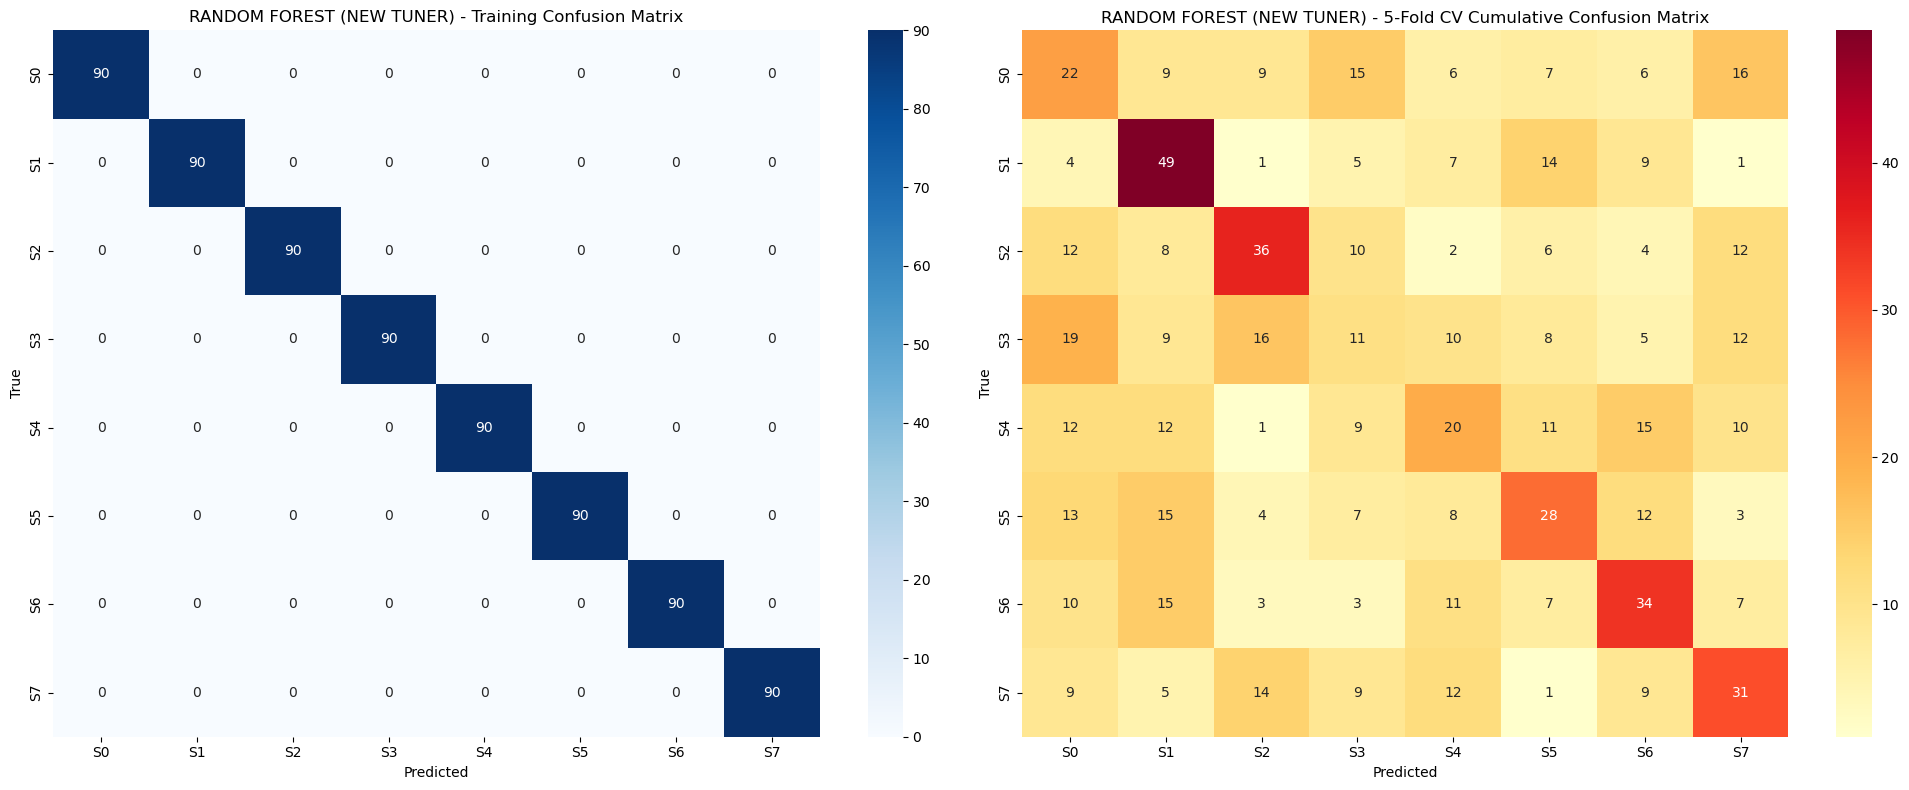

In [89]:
best_rf, params_rf = tune_random_forest(
    X_scaled=X_train_scaled,
    y_train=y_train,
    n_estimators_list=[50,100,200],
    criteria=["gini"],
    max_depth_range=(1,200),
    folds=5
)

rf_results = evaluate_model_with_cv(best_rf, X_train_scaled, y_train, np.unique(y_train))
print_evaluation_report(rf_results, "RANDOM FOREST (NEW TUNER)")


In [90]:
print_best_model_info(best_rf, params_rf, model_name="RANDOM FOREST")


RANDOM FOREST - BEST MODEL INFO
Best Parameters:
  n_estimators: 200
  criterion: gini
  max_depth: 133

Model Object:
RandomForestClassifier(max_depth=133, n_estimators=200, random_state=2025)


# GAUSSIAN NB


GAUSSIAN NB - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.2764
Precision: 0.2639
Recall   : 0.2764
F1-Score : 0.2477

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.1958 ± 0.0330
Precision: 0.1920 ± 0.0521
Recall   : 0.1958 ± 0.0330
F1-Score : 0.1745 ± 0.0324
Correct Predictions per Fold: 28.20 ± 4.75

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.2477
CV F1   : 0.1745
Overfitting Gap (Train F1 - CV F1): 0.0732
 Overfitting is minimal — good generalization


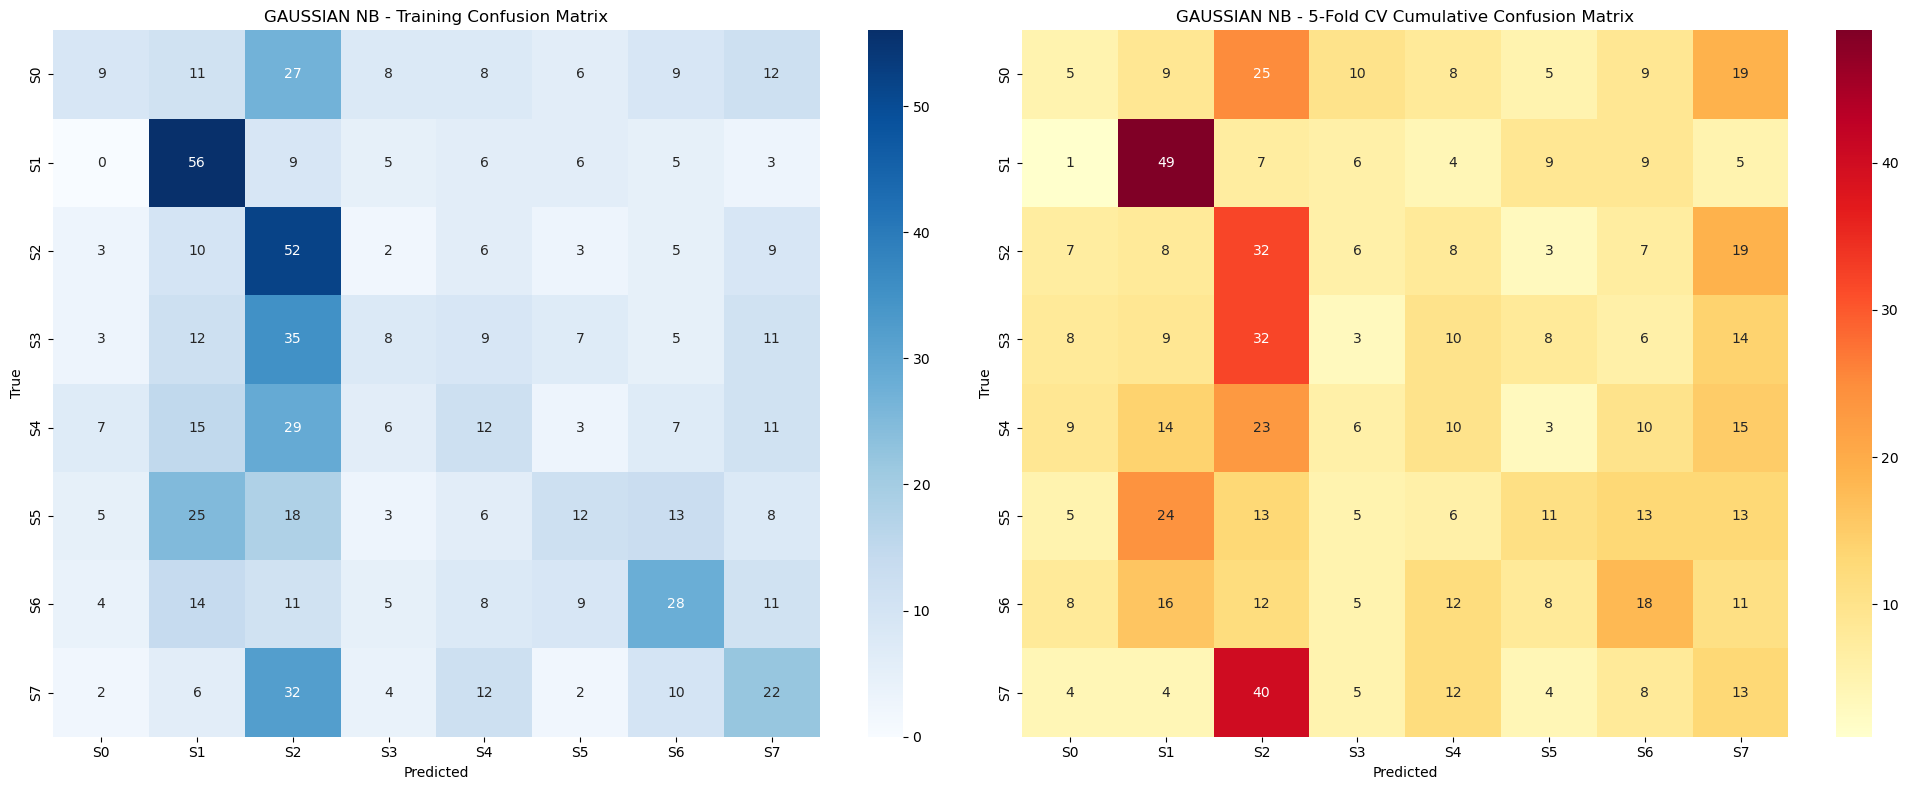

In [91]:
best_nb, params_nb = tune_model_binary_search(
    model_class=GaussianNB,
    X_scaled=X_train_scaled,
    y_train=y_train,
    model_name="GAUSSIAN NB",
    discrete_params={},
    core_param_name="var_smoothing",
    core_param_range=(-100, 100),
    core_param_type="log"
)



nb_results = evaluate_model_with_cv(best_nb, X_train_scaled, y_train, np.unique(y_train))
print_evaluation_report(nb_results, "GAUSSIAN NB")


In [92]:
print_best_model_info(best_nb, params_nb, model_name="GAUSSIAN NB")


GAUSSIAN NB - BEST MODEL INFO
Best Parameters:
  var_smoothing: 4.641588833612753e-34

Model Object:
GaussianNB(var_smoothing=4.641588833612753e-34)


# ensemble learning

In [ ]:

from sklearn.base import clone
import numpy as np

model_objects = {
    "lr":  best_lr,
    "svm": best_svm,
    "rf":  best_rf,
    "knn": best_knn,
    "nb":  best_nb
}

model_f1_scores_cv = {}   #store 5 fold F1
model_results_cv = {}     # evaluate_model_with_cv dictionary
for name, mdl in model_objects.items():

    results = evaluate_model_with_cv(
        model=mdl,
        X_scaled=X_train_scaled,
        y=y_train,
        class_labels=np.unique(y_train),
        folds=5
    )

    cv_f1 = np.mean(results["cv_metrics"]["f1"])
    model_f1_scores_cv[name] = cv_f1
    model_results_cv[name] = results


**Hard Voting (equal weight,f1 weight)**

In [94]:
from sklearn.ensemble import VotingClassifier

#  Hard Voting: Equal Weights 
hard_equal = VotingClassifier(
    estimators=[
        ('lr', model_objects['lr']),
        ('svm', model_objects['svm']),
        ('knn', model_objects['knn']),
        ('rf', model_objects['rf']),
        ('nb', model_objects['nb']),
    ],
    voting='hard',
    weights=[1,1,1,1,1]
)
hard_equal.fit(X_train_scaled, y_train)

hard_equal_results = evaluate_model_with_cv(
    hard_equal, X_train_scaled, y_train, np.unique(y_train), folds=5
)


# ===== Hard Voting: F1 Weighted =====

model_order = ["lr", "svm", "knn", "rf", "nb"]
f1_values = np.array([model_f1_scores_cv[m] for m in model_order])

softmax_temp = 5
exp_scores = np.exp(f1_values * softmax_temp)
weights_f1 = exp_scores / np.min(exp_scores)   #turning to ≥1

hard_weighted = VotingClassifier(
    estimators=[
        ('lr', model_objects['lr']),
        ('svm', model_objects['svm']),
        ('knn', model_objects['knn']),
        ('rf', model_objects['rf']),
        ('nb', model_objects['nb']),
    ],
    voting='hard',
    weights=weights_f1
)
hard_weighted.fit(X_train_scaled, y_train)

hard_weighted_results = evaluate_model_with_cv(
    hard_weighted, X_train_scaled, y_train, np.unique(y_train), folds=5
)


**the result of hard voting equl**


HARD VOTING ENSEMBLE (Equal Weights) - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.5319
Precision: 0.5376
Recall   : 0.5319
F1-Score : 0.5220

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.3111 ± 0.0155
Precision: 0.3123 ± 0.0164
Recall   : 0.3111 ± 0.0155
F1-Score : 0.2949 ± 0.0148
Correct Predictions per Fold: 44.80 ± 2.23

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.5220
CV F1   : 0.2949
Overfitting Gap (Train F1 - CV F1): 0.2270
  Model is severely overfitting


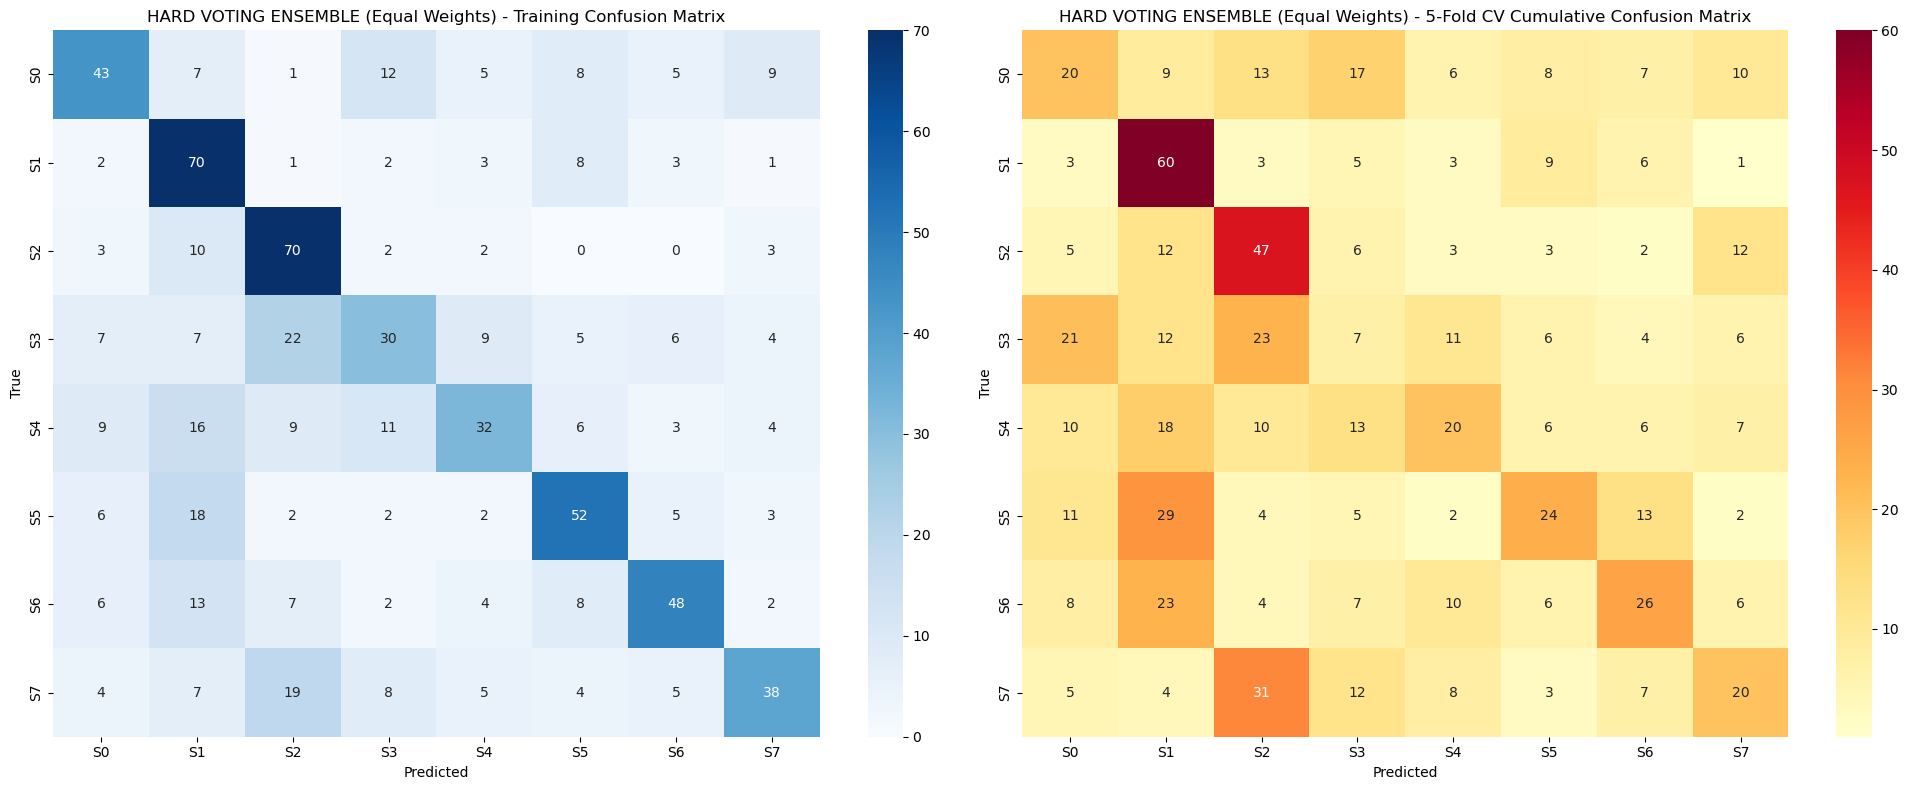

In [95]:
print_evaluation_report(hard_equal_results, 
                        model_name="HARD VOTING ENSEMBLE (Equal Weights)")



**the result of hard_weighted**


HARD VOTING ENSEMBLE (F1-Weighted) - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.5569
Precision: 0.5569
Recall   : 0.5569
F1-Score : 0.5485

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.3125 ± 0.0158
Precision: 0.3041 ± 0.0190
Recall   : 0.3125 ± 0.0158
F1-Score : 0.2979 ± 0.0156
Correct Predictions per Fold: 45.00 ± 2.28

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.5485
CV F1   : 0.2979
Overfitting Gap (Train F1 - CV F1): 0.2506
  Model is severely overfitting


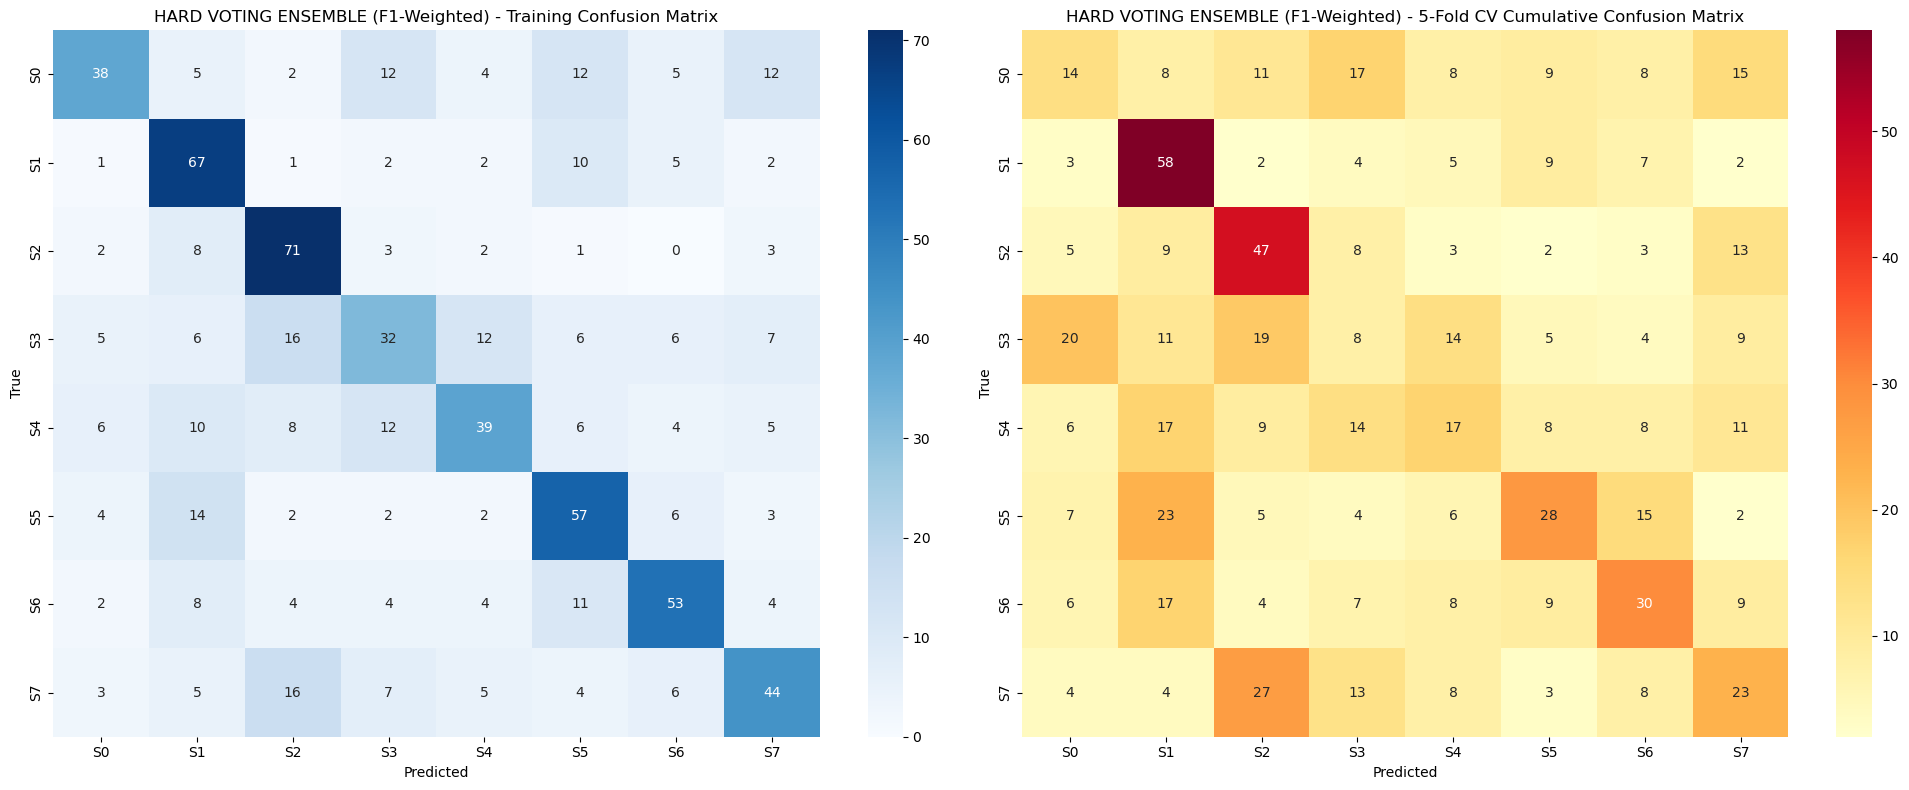

In [96]:
print_evaluation_report(hard_weighted_results, 
                        model_name="HARD VOTING ENSEMBLE (F1-Weighted)")

**Hard Voting (equal weight,f1 weight)**

In [97]:
# Soft Voting: Equal 
soft_equal = VotingClassifier(
    estimators=[
        ('lr', model_objects['lr']),
        ('svm', model_objects['svm']),
        ('knn', model_objects['knn']),
        ('rf', model_objects['rf']),
        ('nb', model_objects['nb']),
    ],
    voting='soft',
    weights=[1,1,1,1,1]
)
soft_equal.fit(X_train_scaled, y_train)

soft_equal_results = evaluate_model_with_cv(
    soft_equal, X_train_scaled, y_train, np.unique(y_train), folds=5
)


# Soft Voting: F1-Weighted

soft_weighted = VotingClassifier(
    estimators=[
        ('lr', model_objects['lr']),
        ('svm', model_objects['svm']),
        ('knn', model_objects['knn']),
        ('rf', model_objects['rf']),
        ('nb', model_objects['nb']),
    ],
    voting='soft',
    weights=weights_f1
)
soft_weighted.fit(X_train_scaled, y_train)

soft_weighted_results = evaluate_model_with_cv(
    soft_weighted, X_train_scaled, y_train, np.unique(y_train), folds=5
)


**result of soft_voting weighted**


SOFT VOTING ENSEMBLE (F1-Weighted) - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.9403
Precision: 0.9480
Recall   : 0.9403
F1-Score : 0.9419

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.3236 ± 0.0150
Precision: 0.3172 ± 0.0206
Recall   : 0.3236 ± 0.0150
F1-Score : 0.3072 ± 0.0135
Correct Predictions per Fold: 46.60 ± 2.15

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.9419
CV F1   : 0.3072
Overfitting Gap (Train F1 - CV F1): 0.6347
  Model is severely overfitting


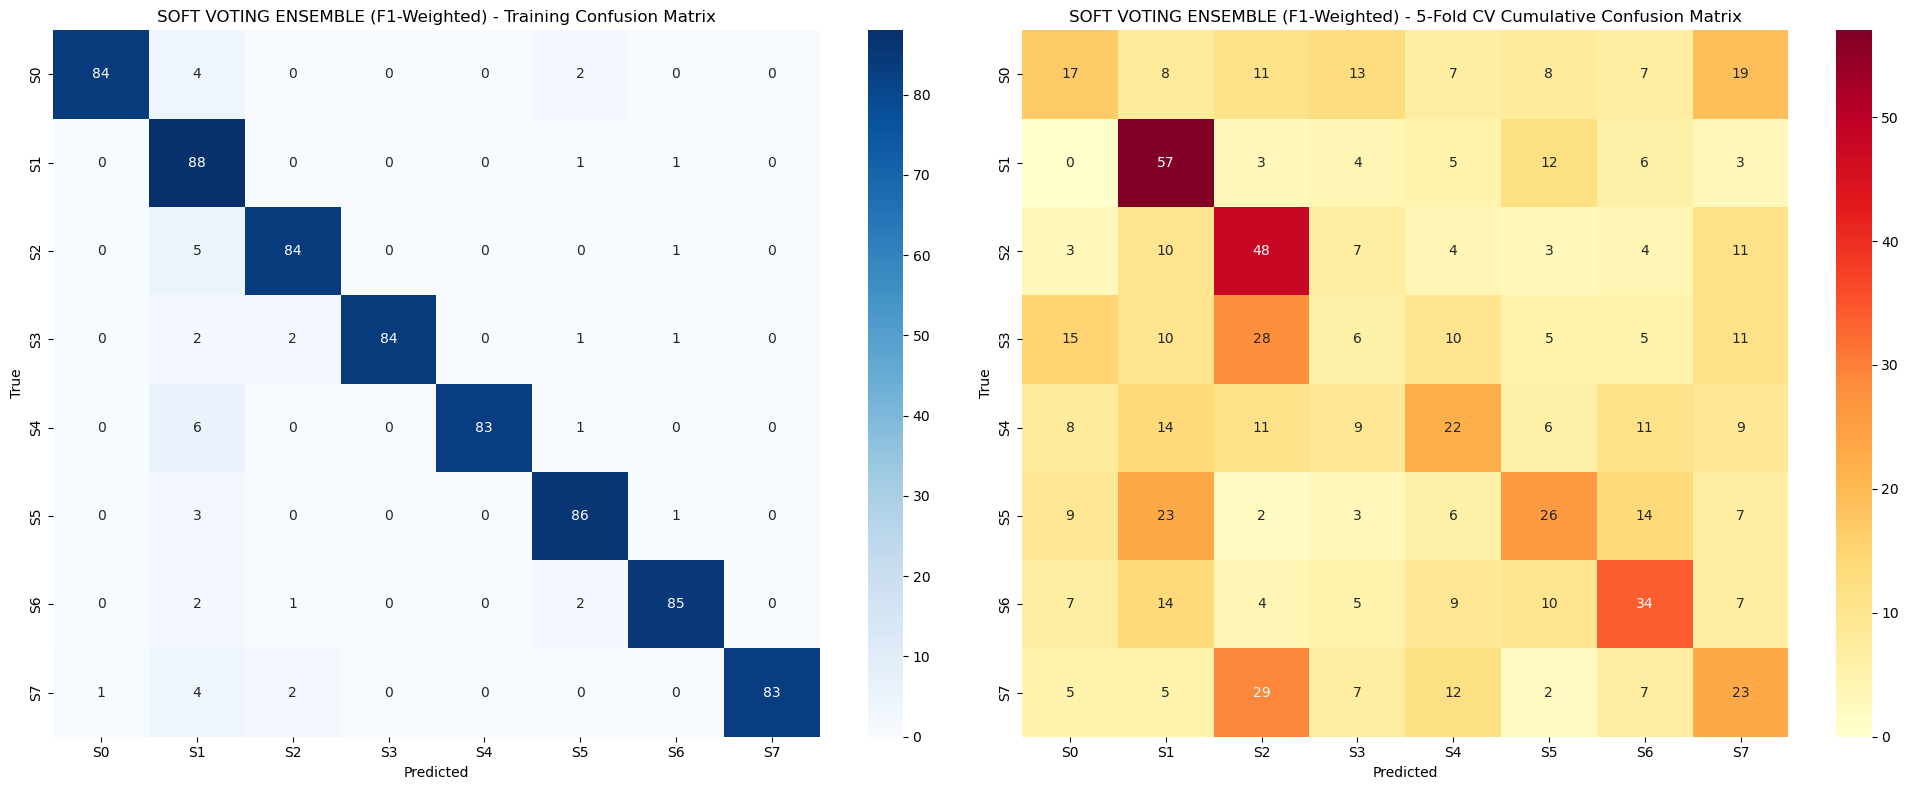

In [98]:
print_evaluation_report(soft_weighted_results, 
                        "SOFT VOTING ENSEMBLE (F1-Weighted)")

**result of soft_voting equal**


SOFT VOTING ENSEMBLE (Equal Weights) - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.8139
Precision: 0.8291
Recall   : 0.8139
F1-Score : 0.8156

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.2917 ± 0.0390
Precision: 0.2889 ± 0.0560
Recall   : 0.2917 ± 0.0390
F1-Score : 0.2729 ± 0.0389
Correct Predictions per Fold: 42.00 ± 5.62

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.8156
CV F1   : 0.2729
Overfitting Gap (Train F1 - CV F1): 0.5427
  Model is severely overfitting


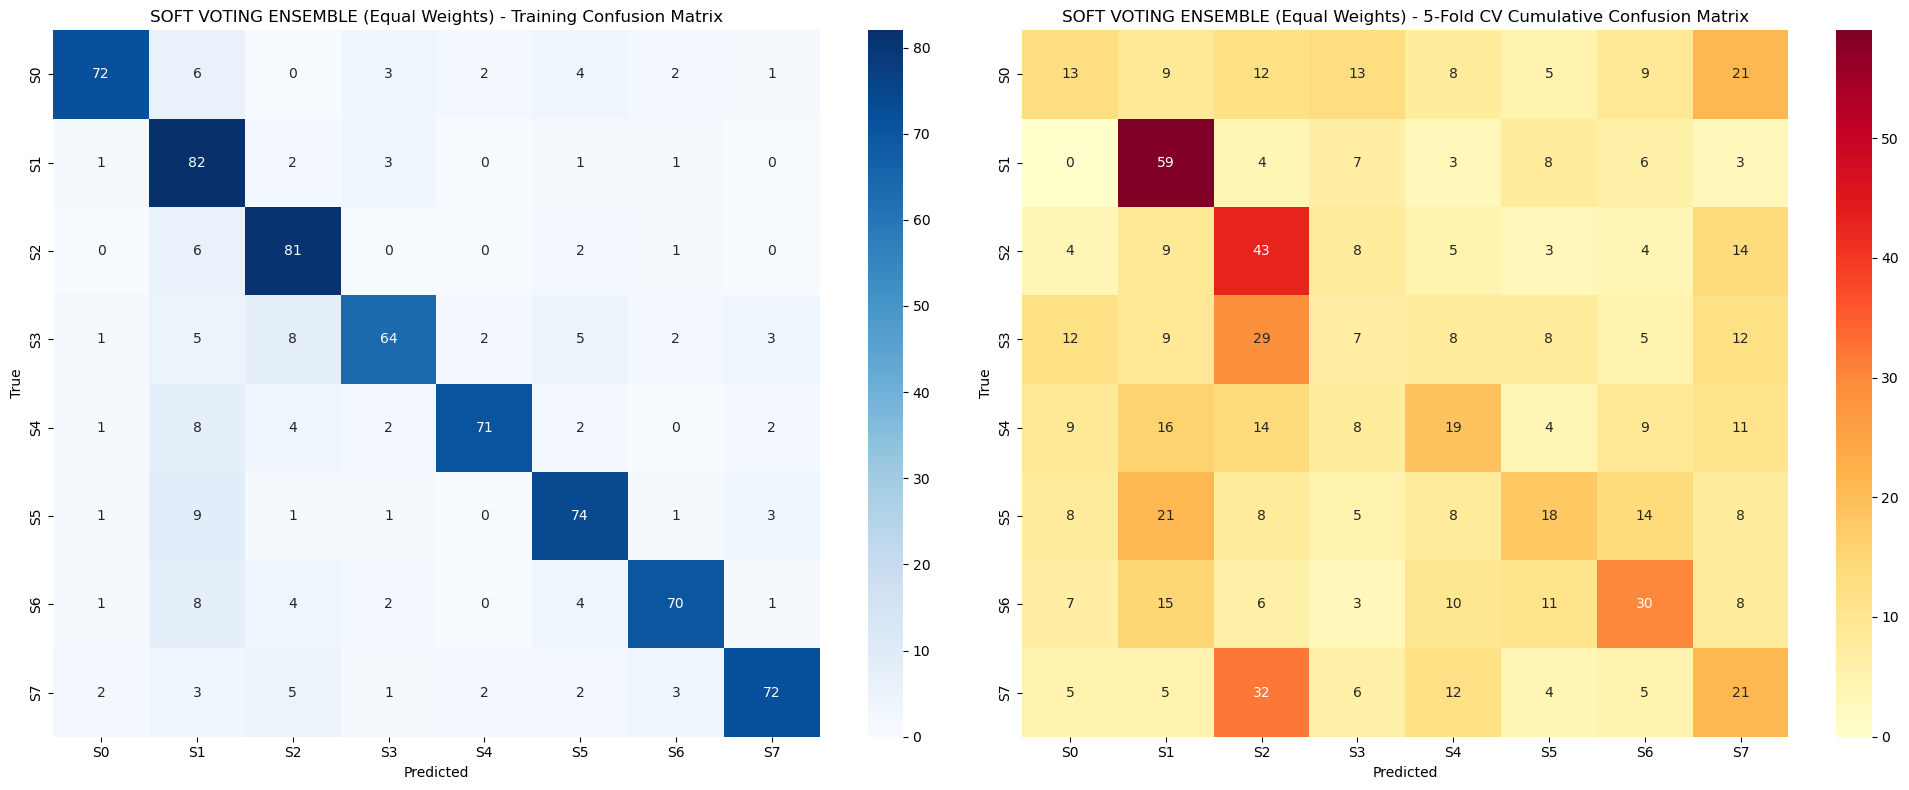

In [99]:
print_evaluation_report(soft_equal_results, "SOFT VOTING ENSEMBLE (Equal Weights)")

**stacking**

In [100]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# STACKING ENSEMBLE 

stacking_estimators = [
    ('lr', model_objects['lr']),
    ('svm', model_objects['svm']),
    ('knn', model_objects['knn']),
    ('rf', model_objects['rf']),
    ('nb', model_objects['nb']),
]

# （Stacking ）
final_estimator = LogisticRegression(max_iter=2000, random_state=2025)

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=final_estimator,
    stack_method="auto",   # auto  predict_proba / decision_function 
    passthrough=False,      
    n_jobs=-1
)

stacking_model.fit(X_train_scaled, y_train)

stacking_results = evaluate_model_with_cv(
    stacking_model,
    X_train_scaled,
    y_train,
    np.unique(y_train),
    folds=5
)



STACKING ENSEMBLE - FINAL MODEL EVALUATION (TRAIN + CV)

[TRAINING SET PERFORMANCE]
--------------------------------------------------------------------------------
Accuracy : 0.7486
Precision: 0.7229
Recall   : 0.7486
F1-Score : 0.7346

[AVERAGE METRICS ACROSS 5 FOLDS]
--------------------------------------------------------------------------------
Accuracy : 0.3667 ± 0.0403
Precision: 0.3537 ± 0.0386
Recall   : 0.3667 ± 0.0403
F1-Score : 0.3491 ± 0.0403
Correct Predictions per Fold: 52.80 ± 5.81

[OVERFITTING ANALYSIS]
--------------------------------------------------------------------------------
Train F1: 0.7346
CV F1   : 0.3491
Overfitting Gap (Train F1 - CV F1): 0.3854
  Model is severely overfitting


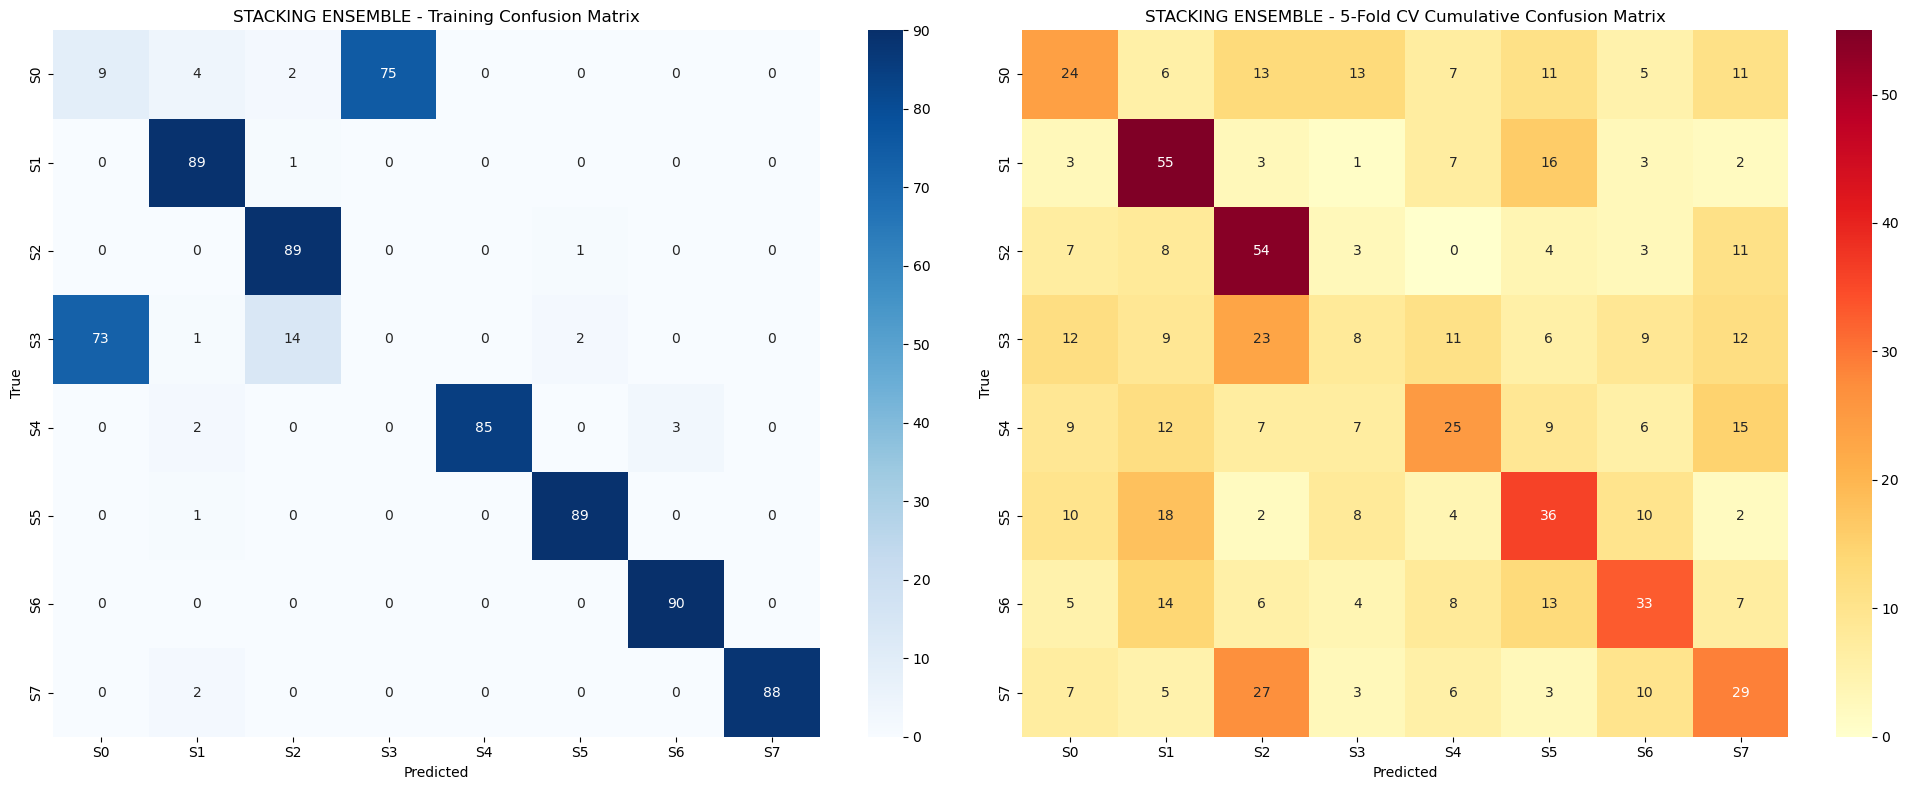

In [101]:
print_evaluation_report(stacking_results, "STACKING ENSEMBLE")

In [102]:
def plot_model_scores(df):
    plt.figure(figsize=(12, 6))

    x = np.arange(len(df))

    fig, ax1 = plt.subplots(figsize=(12, 6))

    
    # Train / CV Accuracy
    ax1.bar(x - 0.2, df["Train Acc"], width=0.4, label="Train Accuracy", alpha=0.7)
    ax1.bar(x + 0.2, df["CV Acc"], width=0.4, label="CV Accuracy", alpha=0.7)

    ax1.set_ylabel("Accuracy")
    ax1.set_xlabel("Model")
    ax1.set_xticks(x)
    ax1.set_xticklabels(df["Model"], rotation=30)
    ax1.set_title("Model Accuracy & Overfitting Gap")
    ax1.grid(axis='y', linestyle='--', alpha=0.4)


    #Overfitting Gap
    ax2 = ax1.twinx()  
    ax2.plot(x, df["Overfitting Gap"], color="red", marker="o",
             linewidth=2.5, label="Overfitting Gap (Train F1 - CV F1)")

    ax2.set_ylabel("Overfitting Gap (F1 Difference)", color="red")
    ax2.tick_params(axis='y', labelcolor='red')

  
    lines_labels = ax1.get_legend_handles_labels()
    lines_labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_labels[0] + lines_labels2[0],
               lines_labels[1] + lines_labels2[1],
               loc="upper left")

    plt.tight_layout()
    plt.show()


In [103]:
# Extract scores into DataFrame
def extract_scores(results_dict):
    records = []

    for model_name, res in results_dict.items():
        train_acc = res["train_metrics"]["accuracy"]
        train_f1  = res["train_metrics"]["f1"]

        cv_acc_mean = np.mean(res["cv_metrics"]["accuracy"])
        cv_f1_mean  = np.mean(res["cv_metrics"]["f1"])

        records.append({
            "Model": model_name,
            "Train Acc": train_acc,
            "CV Acc": cv_acc_mean,
            "Train F1": train_f1,
            "CV F1": cv_f1_mean,
            "Overfitting Gap": train_f1 - cv_f1_mean   
        })

    return pd.DataFrame(records)



                 Model  Train Acc    CV Acc  Train F1     CV F1  \
0  Hard Voting (Equal)   0.531944  0.311111  0.521990  0.294942   
1     Hard Voting (F1)   0.556944  0.312500  0.548549  0.297906   
2  Soft Voting (Equal)   0.813889  0.291667  0.815634  0.272934   
3     Soft Voting (F1)   0.940278  0.323611  0.941937  0.307221   
4    Stacking Ensemble   0.748611  0.366667  0.734554  0.349108   

   Overfitting Gap  
0         0.227048  
1         0.250644  
2         0.542700  
3         0.634716  
4         0.385447  


<Figure size 1200x600 with 0 Axes>

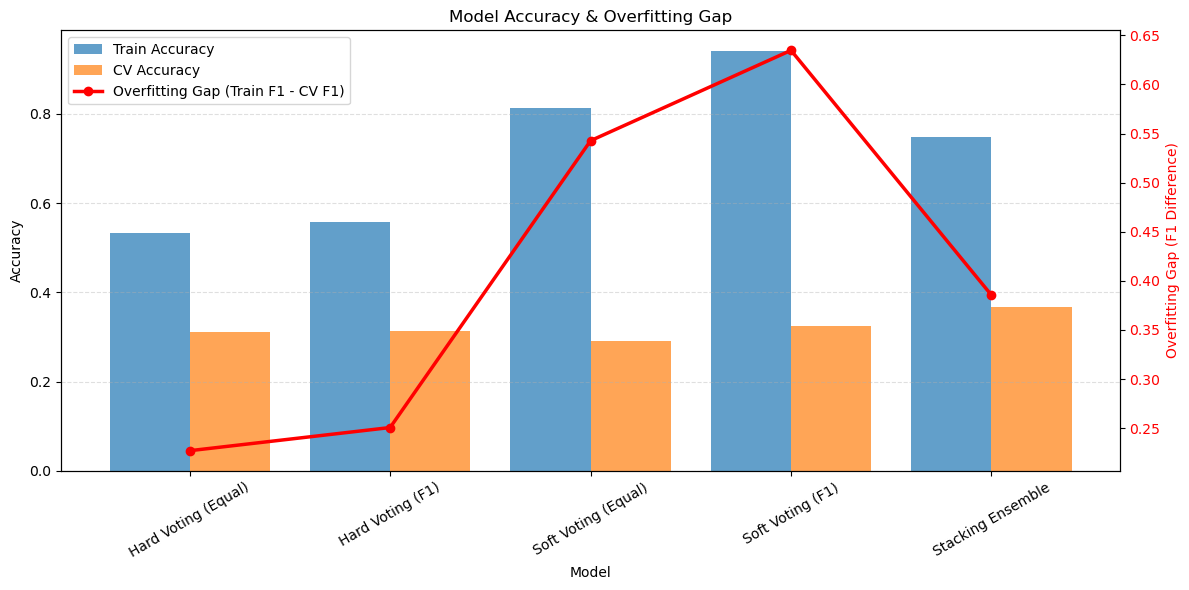

In [104]:
# Compile results
results_dict = {
    "Hard Voting (Equal)": hard_equal_results,
    "Hard Voting (F1)": hard_weighted_results,
    "Soft Voting (Equal)": soft_equal_results,
    "Soft Voting (F1)": soft_weighted_results,
    "Stacking Ensemble": stacking_results,
}

df_analysis = extract_scores(results_dict)

print(df_analysis)

plot_model_scores(df_analysis)



## Final Model Evaluation on Test Set
Here I use the stacking ensemble method because it has a lower overfitting coefficient and better performance on the training set. Use the best ensemble model (Hard Voting with F1-Weighted) trained on the entire training set to evaluate performance on the held-out test set.

In [ ]:
def evaluate_on_test_set(model, X_train, y_train, X_test, y_test, model_name="Model"):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    from sklearn.metrics import classification_report, confusion_matrix
    
    # Train on entire training set
    model.fit(X_train, y_train)
    
    # Predict  test set
    y_pred = model.predict(X_test)
    
    #  metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Generate  report
    class_labels = np.unique(y_train)
    target_names = [f"Song {i}" for i in class_labels]
    report_text = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Return all results
    results = {
        'model_name': model_name,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'true_labels': y_test,
        'classification_report': report_text,
        'class_labels': class_labels,
        'target_names': target_names
    }
    
    return results

FINAL TEST SET EVALUATION: Hard Voting Ensemble (F1-Weighted)

--------------------------------------------------------------------------------
TEST SET PERFORMANCE SUMMARY
--------------------------------------------------------------------------------
Accuracy:  0.3250
Precision: 0.3145 
F1-Score:  0.3155 
--------------------------------------------------------------------------------

              precision    recall  f1-score   support

      Song 0       0.55      0.60      0.57        10
      Song 1       0.36      0.40      0.38        10
      Song 2       0.23      0.30      0.26        10
      Song 3       0.00      0.00      0.00        10
      Song 4       0.12      0.10      0.11        10
      Song 5       0.27      0.40      0.32        10
      Song 6       0.56      0.50      0.53        10
      Song 7       0.43      0.30      0.35        10

    accuracy                           0.33        80
   macro avg       0.31      0.33      0.32        80
weighted avg

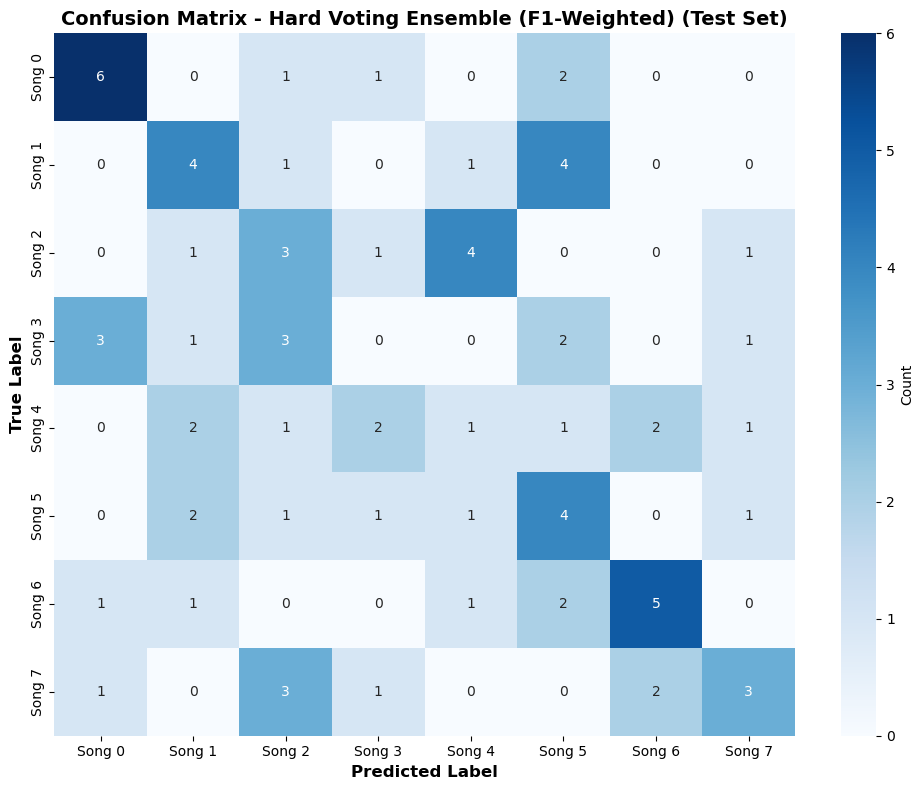


PER-CLASS CORRECT PREDICTIONS
Song 0: 6/10 (60.0%)
Song 1: 4/10 (40.0%)
Song 2: 3/10 (30.0%)
Song 3: 0/10 (0.0%)
Song 4: 1/10 (10.0%)
Song 5: 4/10 (40.0%)
Song 6: 5/10 (50.0%)
Song 7: 3/10 (30.0%)


In [106]:
# Evaluate Hard Voting (F1-Weighted) on Test Set
final_test_results = evaluate_on_test_set(
    model=hard_equal,
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="Hard Voting Ensemble (F1-Weighted)"
)


print("="*80)
print(f"FINAL TEST SET EVALUATION: {final_test_results['model_name']}")
print("="*80)

# Summary metrics
print("\n" + "-"*80)
print("TEST SET PERFORMANCE SUMMARY")
print("-"*80)
print(f"Accuracy:  {final_test_results['test_accuracy']:.4f}")
print(f"Precision: {final_test_results['test_precision']:.4f} ")
print(f"F1-Score:  {final_test_results['test_f1']:.4f} ")
print("-"*80)

# Detailed classification report
print("\n" + "="*80)
print("="*80)
print(final_test_results['classification_report'])

# Confusion matrix visualization
print("\n" + "="*80)
print("CONFUSION MATRIX VISUALIZATION")
print("="*80)

plt.figure(figsize=(10, 8))
sns.heatmap(final_test_results['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=final_test_results['target_names'], 
            yticklabels=final_test_results['target_names'],
            cbar_kws={'label': 'Count'})
plt.title(f"Confusion Matrix - {final_test_results['model_name']} (Test Set)", 
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print per-class performance
print("\n" + "="*80)
print("PER-CLASS CORRECT PREDICTIONS")
print("="*80)
cm = final_test_results['confusion_matrix']
for i, label in enumerate(final_test_results['target_names']):
    total = cm[i].sum()
    correct = cm[i, i]
    accuracy = correct / total if total > 0 else 0
    print(f"{label}: {correct}/{total} ({accuracy*100:.1f}%)")

The model was selected on the training set, and Hardvoting has been chosen as the voting method. In the next cell, I will train all the base models and the ensemble model on the training set to further explore the performance of all models

In [ ]:
print("\n" + "="*80)
print("VALIDATING ALL MODELS ON TEST SET")
print("="*80)

from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models_to_test = {
    "Logistic Regression": best_lr,
    "SVM": best_svm,
    "Random Forest": best_rf,
    "KNN": best_knn,
    "Naive Bayes": best_nb,
    "Stacking Ensemble": stacking_model,
    "Hard Voting (Equal)": hard_equal,
    "Hard Voting (F1-Weighted)": hard_weighted,
    "Soft Voting (Equal)": soft_equal,
    "Soft Voting (F1-Weighted)": soft_weighted,
}

test_results_summary = []

for model_name, model in models_to_test.items():

    print(f"\n{model_name}:")
    print("-" * 50)

    y_pred_test = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    test_results_summary.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })



df_results = pd.DataFrame(test_results_summary)




VALIDATING ALL MODELS ON TEST SET

Logistic Regression:
--------------------------------------------------
  Accuracy:  0.2625
  Precision: 0.2861
  Recall:    0.2625
  F1-Score:  0.2557

SVM:
--------------------------------------------------
  Accuracy:  0.3000
  Precision: 0.3335
  Recall:    0.3000
  F1-Score:  0.3109

Random Forest:
--------------------------------------------------
  Accuracy:  0.3125
  Precision: 0.3037
  Recall:    0.3125
  F1-Score:  0.3007

KNN:
--------------------------------------------------
  Accuracy:  0.2750
  Precision: 0.2987
  Recall:    0.2750
  F1-Score:  0.2656

Naive Bayes:
--------------------------------------------------
  Accuracy:  0.2125
  Precision: 0.2507
  Recall:    0.2125
  F1-Score:  0.1988

Stacking Ensemble:
--------------------------------------------------
  Accuracy:  0.3125
  Precision: 0.3132
  Recall:    0.3125
  F1-Score:  0.3079

Hard Voting (Equal):
--------------------------------------------------
  Accuracy:  0.3250
  

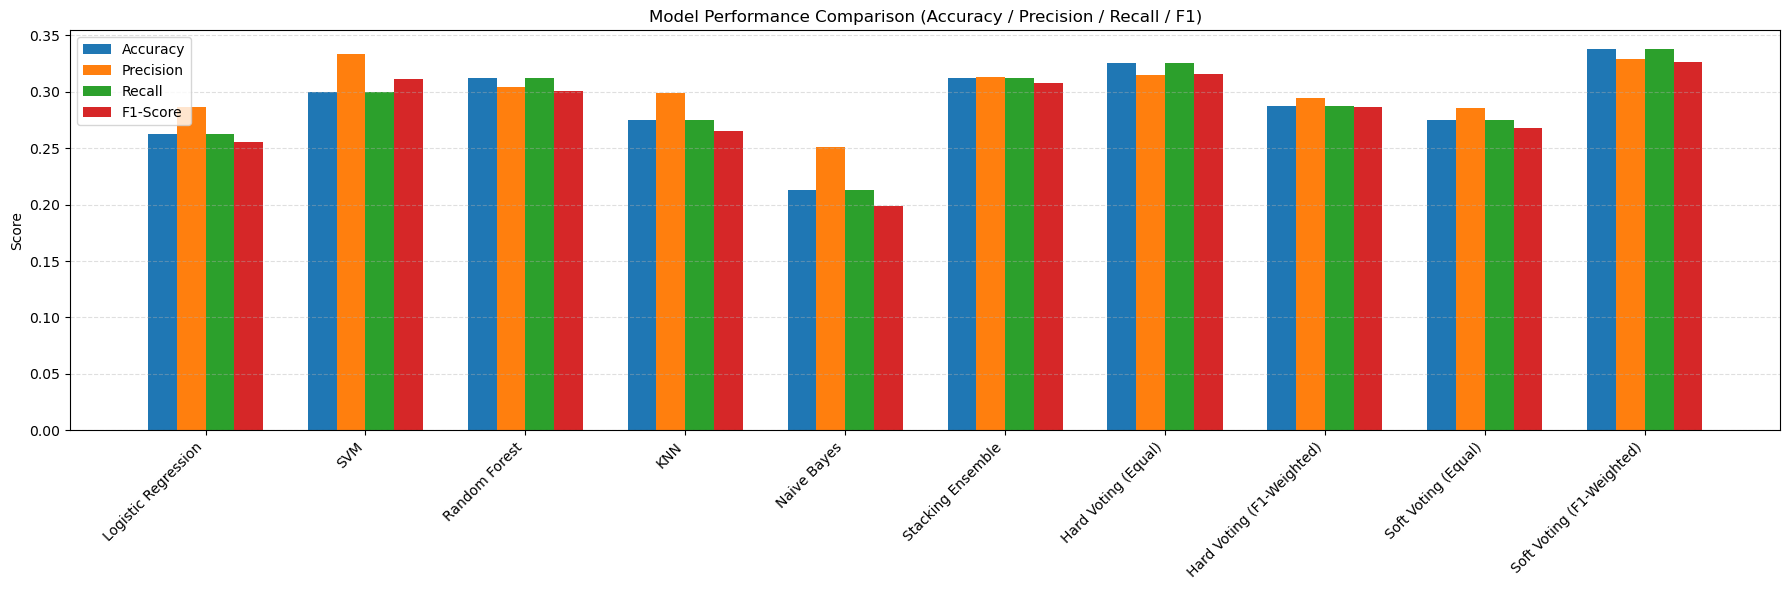

In [108]:
# NEW — Grouped Bar Chart (One graph, 4 bars per model)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
num_models = len(df_results)
num_metrics = len(metrics)

x = np.arange(num_models)
width = 0.18  

plt.figure(figsize=(18, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + (i - 1.5) * width, df_results[metric], width, label=metric)

plt.xticks(x, df_results["Model"], rotation=45, ha='right')
plt.ylabel("Score")
plt.title("Model Performance Comparison (Accuracy / Precision / Recall / F1)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


**The following cell presents a radar chart showing the performance of all models on the test set.**

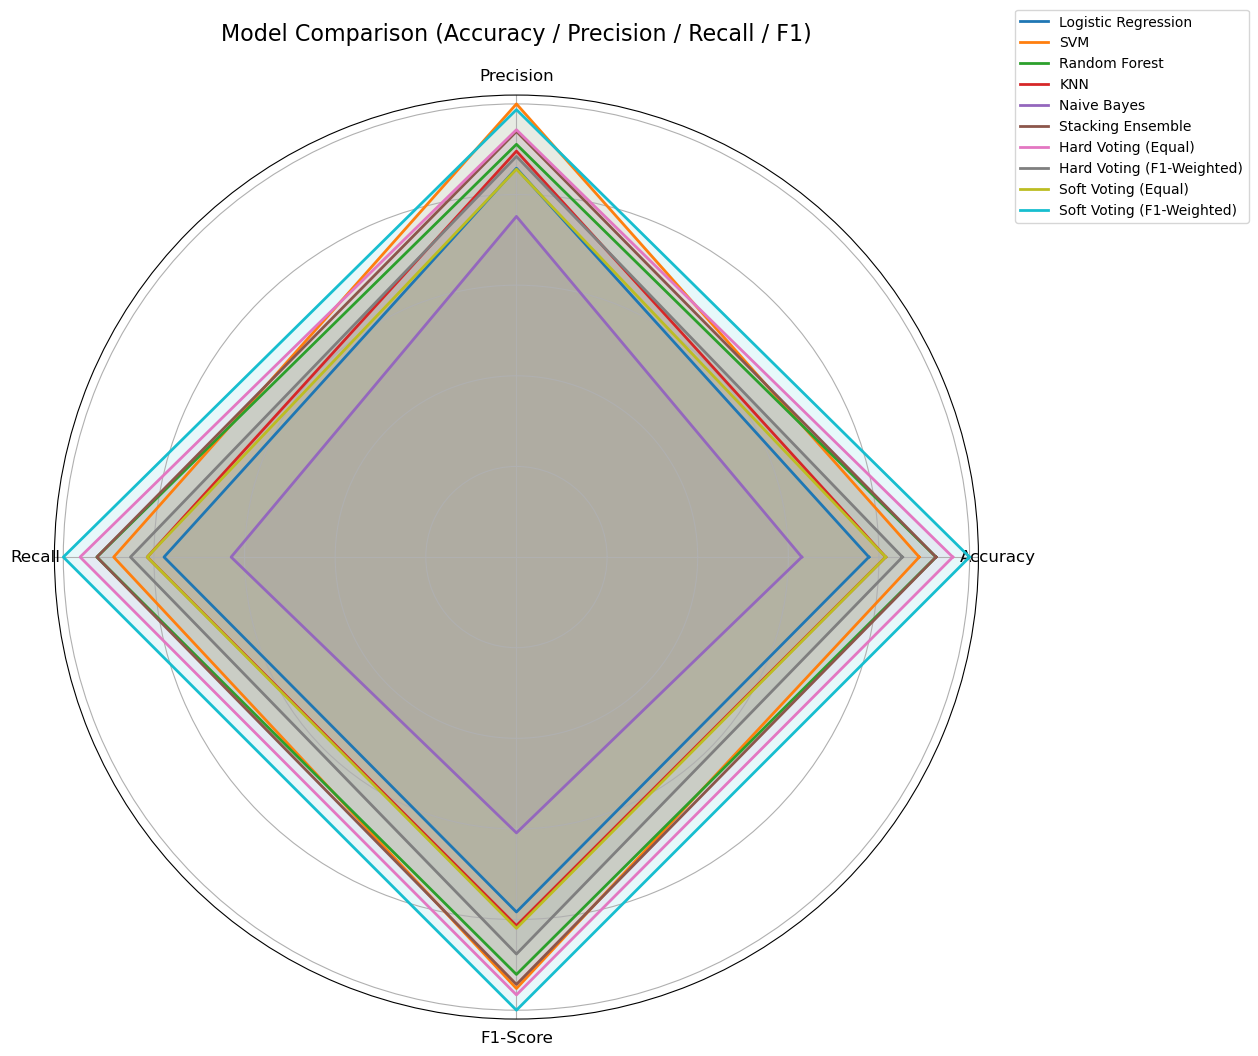

In [ ]:
# Radar Chart 
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]


df_norm = df_results.copy()
for m in metrics:
    max_val = df_norm[m].max()
    if max_val > 0:
        df_norm[m] = df_norm[m] / max_val

labels = df_results["Model"]
num_models = len(df_results)
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  

plt.figure(figsize=(12, 12))
ax = plt.subplot(111, polar=True)

for i, row in df_norm.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_yticklabels([])
ax.set_title("Model Comparison (Accuracy / Precision / Recall / F1)", fontsize=16, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()


The following is a complete function that uses a model (in the example below, a stacking ensemble model) to take the file path of a music file as input and outputs the predicted song label, thus accomplishing the initial task.

In [ ]:
def predict_song_final(audio_path, return_details=False):
    import numpy as np

    try:
        features, _ = extract_audio_features(
            audio_path,
            sr=22050,
            scale_audio=True,
            pitch_method='librosa',
            max_duration=MAX_AUDIO_DURATION,
        )
        X_raw = np.array([features])
    except Exception as e:
        return {'error': str(e), 'song': None}
    
    

    X_scaled = scaler.transform(X_raw)
    
    
    y_pred = hard_equal.predict(X_scaled)[0]
    predictions = []
    for estimator_name, estimator in hard_equal.estimators:
        pred = estimator.predict(X_scaled)[0]
        predictions.append(pred)
    predictions = np.array(predictions)

    # Reverse mapping: label → song name
    label_to_song = {v: k for k, v in song_labels.items()}
    predicted_song = label_to_song[y_pred]
    
    if return_details:
        return {
            'song': predicted_song,
            'label': int(y_pred)
        }
    else:
        return predicted_song


print("="*80)
print("FINAL SONG PREDICTION (Hard Voting stacking)")
print("="*80)

audio_path = 'MLEndHWII_sample_800/S1_whistle_2_Friend.wav'
result = predict_song_final(audio_path, return_details=True)

if 'error' not in result:
    print(f"Target audio: {audio_path}")
    print(f"Predicted Song: {result['song']}")
    print("="*80)
else:
    print(f"Error: {result['error']}")

FINAL SONG PREDICTION (Hard Voting stacking)
Target audio: MLEndHWII_sample_800/S1_whistle_2_Friend.wav
Predicted Song: Married


Below, using the Soft Voting (F1-Weighted) prediction method, display the predicted probabilities alongside the song predictions

In [ ]:


from sklearn.ensemble import VotingClassifier


model_order = ["lr", "svm", "knn", "rf", "nb"]
f1_values = np.array([model_f1_scores_cv[m] for m in model_order])  # CV Macro-F1

softmax_temp = 5.0
exp_scores = np.exp(f1_values * softmax_temp)
weights_f1 = exp_scores / np.min(exp_scores)  

soft_weighted = VotingClassifier(
    estimators=[
        ('lr', model_objects['lr']),
        ('svm', model_objects['svm']),
        ('knn', model_objects['knn']),
        ('rf', model_objects['rf']),
        ('nb', model_objects['nb']),
    ],
    voting='soft',
    weights=weights_f1
)
soft_weighted.fit(X_train_scaled, y_train)  # fit on the already-scaled train set

audio_path = 'MLEndHWII_sample_800/S1_whistle_2_Friend.wav'  
features, _ = extract_audio_features(
    audio_path,
    sr=22050,
    scale_audio=True,
    pitch_method='librosa',
    max_duration=MAX_AUDIO_DURATION,
)
X_raw = np.array([features])
X_scaled = scaler.transform(X_raw)  

# Predict label 
proba = soft_weighted.predict_proba(X_scaled)[0]           
y_pred = soft_weighted.predict(X_scaled)[0]

# Map label 
label_to_song = {v: k for k, v in song_labels.items()}     
predicted_song = label_to_song[y_pred]

print("="*80)
print("SOFT VOTING (F1-Weighted) PREDICTION")
print("="*80)
print(f"Target audio: {audio_path}")
print(f"Predicted Song: {predicted_song} ")

# Print per-song probabilities aligned with label order
print("\nPer-song probabilities:")

classes_order = soft_weighted.classes_

print("\nSorted probabilities (desc):")
sorted_idx = np.argsort(proba)[::-1]
for idx in sorted_idx:
    cls_label = classes_order[idx]
    song_name = label_to_song.get(cls_label, f"label_{cls_label}")
    print(f"  {song_name}: {proba[idx]:.4f}")

SOFT VOTING (F1-Weighted) PREDICTION
Target audio: MLEndHWII_sample_800/S1_whistle_2_Friend.wav
Predicted Song: Friend 

Per-song probabilities:

Sorted probabilities (desc):
  Friend: 0.2268
  Married: 0.2195
  RememberMe: 0.1565
  NewYork: 0.1140
  Feeling: 0.0970
  TryEverything: 0.0738
  Happy: 0.0603
  Necessities: 0.0522


## Try something new Deep Learning Approach （with a RTX 3090 Server）It can be seen as a deeper exploration from the machnic learning part





3. Data Shapes & Augmentation

During the training process, I applied 6x Time-domain Augmentation to the training set. This involved generating distinct spectrograms by randomly cropping the same audio segment 6 times.

| Dataset Stage | Original Sample Count (Approx.) | Augmentation Strategy | Final Tensor Shape | Description |
| :--- | :---: | :--- | :--- | :--- |
| **Final Test Set** | 80 | None (Fixed Crop) | **(80, 256, 256, 3)** | Used for final evaluation |
| **CV Validation Fold** | 144 | None (Fixed Crop) | **(144, 256, 256, 3)** | Validation set for each fold (1/5 Dev Set) |
| **CV Training Fold** | 576 | **6x Random Crop** | **(3456, 256, 256, 3)** | Training set for each fold (4/5 Dev Set) |

Why I do the Random Crop，for deep learning a large range of data is a must for the training of model

I also use 5-fold validation to tune the parameters its the core logic is similar to above，in this way every element in the train set has been taken as validation at least once which will guarantee the model I adapt performs good in the train set

### model one standard CNN with fixed hand written structure

| Layer Name | Layer Type | Configuration | Input Shape (H, W, C) | Output Shape (H, W, C) | Description of Shape Change |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Input** | InputLayer | - | - | $(256, 256, 3)$ | Raw RGB CQT Spectrogram Input |
| **Block 1** | Conv2D | Filters=32, Kernel=3x3, Padding=Same | $(256, 256, 3)$ | $(256, 256, 32)$ | Feature extraction; size unchanged. |
| | BatchNormalization | - | $(256, 256, 32)$ | $(256, 256, 32)$ | Normalization applied. |
| | Activation | ReLU | $(256, 256, 32)$ | $(256, 256, 32)$ | Non-linearity introduced. |
| **Block 2** | Conv2D | Filters=64, Kernel=3x3, Padding=Same | $(256, 256, 32)$ | $(256, 256, 64)$ | Depth doubled. |
| | BatchNormalization | - | $(256, 256, 64)$ | $(256, 256, 64)$ | Normalization. |
| | Activation | ReLU | $(256, 256, 64)$ | $(256, 256, 64)$ | Non-linearity. |
| | **MaxPooling2D** | Pool Size=(2, 2) | $(256, 256, 64)$ | $(128, 128, 64)$ | **Downsampling 1**: Height/Width halved. |
| **Block 3** | Conv2D | Filters=128, Kernel=3x3, Padding=Same | $(128, 128, 64)$ | $(128, 128, 128)$ | Depth doubled. |
| | BatchNormalization | - | $(128, 128, 128)$ | $(128, 128, 128)$ | Normalization. |
| | Activation | ReLU | $(128, 128, 128)$ | $(128, 128, 128)$ | Non-linearity. |
| | **MaxPooling2D** | Pool Size=(2, 2) | $(128, 128, 128)$ | $(64, 64, 128)$ | **Downsampling 2**: Height/Width halved. |
| **Block 4** | Conv2D | Filters=256, Kernel=3x3, Padding=Same | $(64, 64, 128)$ | $(64, 64, 256)$ | Depth doubled. |
| | BatchNormalization | - | $(64, 64, 256)$ | $(64, 64, 256)$ | Normalization. |
| | Activation | ReLU | $(64, 64, 256)$ | $(64, 64, 256)$ | Non-linearity. |
| **Classification** | GlobalAveragePooling2D | - | $(64, 64, 256)$ | $(256)$ | Dimensionality Reduction: Creates a feature vector. |
| | Dense | Units=$N$ (num_classes), Softmax | $(256)$ | $(N)$ | Final classification probabilities. |


In [16]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tqdm import tqdm
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')

# Set random seeds for reproducibility
tf.random.set_seed(2025)
np.random.seed(2025)

# Global Configuration
CONFIG = {
    "SR": 22050,             # Sample Rate
    "DURATION": 10.0,        # Duration in seconds
    "IMG_SIZE": (256, 256),  # Input image size for CNN
    "BATCH_SIZE": 32,
    "EPOCHS": 40,
    "LR": 1e-3,              # Learning Rate
    "N_FOLDS": 5             # Number of Cross-Validation Folds
}

In [17]:
#Data spliting
data_path = 'MLEndHWII_sample_800/*.wav'
files = sorted(glob.glob(data_path))

# Parse filenames to extract song labels
rows = []
for f in files:
    name = os.path.basename(f)
    parts = name.split("_")
    # Ensure filename has enough parts to extract the song name
    if len(parts) >= 4:
        song = parts[3].split(".")[0]
        rows.append([f, song])
 
df = pd.DataFrame(rows, columns=["path", "song"])
counts = df['song'].value_counts()
df = df[df['song'].isin(counts[counts > 5].index)]

# Create label mapping
unique_songs = sorted(df.song.unique())
label_map = {s: i for i, s in enumerate(unique_songs)}
df["label"] = df["song"].map(label_map)
num_classes = len(unique_songs)

print(f"Total Files: {len(df)}")

# Split data into Dev set (90%) and Final Test set (10%)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=2025)
dev_idx, test_idx = next(splitter.split(df, df["label"]))

dev_df = df.iloc[dev_idx].reset_index(drop=True)   # Used for 5-Fold CV
test_df = df.iloc[test_idx].reset_index(drop=True) # Used for final evaluation

print(f"Dev Set (for 5-Fold): {len(dev_df)}")
print(f"Test Set (Hold-out):  {len(test_df)}")

Total Files: 800
Dev Set (for 5-Fold): 720
Test Set (Hold-out):  80


**core logic CQT extraction truning data to figures**

In [19]:
def extract_cqt_image(path, mode='train'):
    """
    Extracts CQT features from audio.
    mode='train': Performs random cropping for augmentation.
    mode='val': Crops from the beginning (fixed).
    """
    try:
        # Load audio file
        y, _ = librosa.load(path, sr=CONFIG["SR"])
        
        target_len = int(CONFIG["SR"] * CONFIG["DURATION"])
        current_len = len(y)

        if current_len < target_len:
            # Pad audio by tiling if shorter than target duration
            repeats = target_len // current_len + 1
            y = np.tile(y, repeats)[:target_len]
            
        elif current_len > target_len:
            # Crop audio if longer than target duration
            if mode == 'train':
                # Random crop for training
                max_start = current_len - target_len
                start = np.random.randint(0, max_start)
                y = y[start : start + target_len]
            else:
                # Fixed crop (from start) for validation/testing
                y = y[:target_len] 

        # Compute Constant-Q Transform (CQT)
        cqt = np.abs(librosa.cqt(y, sr=CONFIG["SR"], n_bins=84, bins_per_octave=12, hop_length=512))
        cqt_db = librosa.amplitude_to_db(cqt, ref=np.max)
        
        # Normalize to 0-1 range
        min_v, max_v = cqt_db.min(), cqt_db.max()
        cqt_norm = (cqt_db - min_v) / (max_v - min_v + 1e-6)
        
        # Resize and convert to RGB format
        img = cqt_norm[..., np.newaxis]
        img = tf.image.resize(img, CONFIG["IMG_SIZE"]) 
        img = tf.image.grayscale_to_rgb(img) 
        return img.numpy()
        
    except Exception as e:
        # Return a blank image in case of error
        print(f"Error processing {path}: {e}")
        return np.zeros((CONFIG["IMG_SIZE"][0], CONFIG["IMG_SIZE"][1], 3), dtype=np.float32)

In [20]:

dev_data_cache = []

for _, row in tqdm(dev_df.iterrows(), total=len(dev_df), desc="Dev Set"):
    # Generate 6 random crop variants for training
    train_variants = []
    repeats = 6 
    for _ in range(repeats):
        img = extract_cqt_image(row.path, mode='train')
        train_variants.append(img)
        
    # Generate 1 fixed variant for validation
    val_variant = extract_cqt_image(row.path, mode='val')
    
    dev_data_cache.append({
        'train': np.array(train_variants), 
        'val': val_variant,                 
        'label': row.label
    })

print(" Pre-extracting Test Set (Caching)...")
X_test = []
y_test = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test Set"):
    # Use fixed validation mode for final test set
    img = extract_cqt_image(row.path, mode='val')
    X_test.append(img)
    y_test.append(row.label)

X_test = np.array(X_test)
y_test = np.array(y_test)

Dev Set: 100%|██████████| 720/720 [03:16<00:00,  3.66it/s]


 Pre-extracting Test Set (Caching)...


Test Set: 100%|██████████| 80/80 [00:03<00:00, 25.60it/s]


In [6]:
def build_standard_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Block 3
    x = layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Block 4
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Classifier Head
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inp, out, name="Standard_CNN")

In [18]:

def build_standard_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = inp
    
    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inp, out, name="Standard_CNN_MaxPooling")

# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=CONFIG["N_FOLDS"], shuffle=True, random_state=2025)
dev_labels = dev_df['label'].values

fold_accuracies = []
best_val_acc = 0.0
best_model_path = "best_fold_model.h5"

print(f"\nStarting {CONFIG['N_FOLDS']}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(dev_df, dev_labels)):
    print(f"\nFold {fold+1}")
    
    # Prepare training data
    X_train_fold, y_train_fold = [], []
    for i in train_idx:
        item = dev_data_cache[i]
        X_train_fold.extend(item['train'])
        y_train_fold.extend([item['label']] * 6)
        
    # Prepare validation data
    X_val_fold, y_val_fold = [], []
    for i in val_idx:
        item = dev_data_cache[i]
        X_val_fold.append(item['val'])
        y_val_fold.append(item['label'])
        
    X_train_fold = np.array(X_train_fold)
    y_train_fold = np.array(y_train_fold)
    X_val_fold = np.array(X_val_fold)
    y_val_fold = np.array(y_val_fold)
    
    print(f"Train Shape: {X_train_fold.shape}")
    print(f"Val Shape:   {X_val_fold.shape}")
    
    # Reset session and build model
    tf.keras.backend.clear_session()
    model = build_standard_cnn((CONFIG["IMG_SIZE"][0], CONFIG["IMG_SIZE"][1], 3), num_classes)
    
    model.compile(optimizer=optimizers.Adam(learning_rate=CONFIG["LR"]),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    fold_path = f"model_fold_{fold+1}.h5"
    
    # Set up callbacks
    callbacks_list = [
        callbacks.ModelCheckpoint(fold_path, monitor='val_accuracy', save_best_only=True, verbose=0),
        callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
    ]
    
    # Shuffle and train
    idx = np.random.permutation(len(X_train_fold))
    X_train_fold, y_train_fold = X_train_fold[idx], y_train_fold[idx]
    
    model.fit(X_train_fold, y_train_fold, 
              validation_data=(X_val_fold, y_val_fold),
              epochs=CONFIG["EPOCHS"], batch_size=CONFIG["BATCH_SIZE"],
              callbacks=callbacks_list, verbose=0)
    
    # Evaluate best model for this fold
    model.load_weights(fold_path)
    loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Val Acc: {acc*100:.2f}%")
    
    # Save global best model
    if acc > best_val_acc:
        best_val_acc = acc
        model.save_weights(best_model_path)
        print(f"New Best Model Saved!")
        
    gc.collect()

print(f"\nCV Average Accuracy: {np.mean(fold_accuracies)*100:.2f}%")


Starting 5-Fold Cross Validation...

Fold 1
Train Shape: (3456, 256, 256, 3)
Val Shape:   (144, 256, 256, 3)
Fold 1 Val Acc: 31.94%
New Best Model Saved!

Fold 2
Train Shape: (3456, 256, 256, 3)
Val Shape:   (144, 256, 256, 3)
Fold 2 Val Acc: 27.78%

Fold 3
Train Shape: (3456, 256, 256, 3)
Val Shape:   (144, 256, 256, 3)
Fold 3 Val Acc: 27.08%

Fold 4
Train Shape: (3456, 256, 256, 3)
Val Shape:   (144, 256, 256, 3)
Fold 4 Val Acc: 22.92%

Fold 5
Train Shape: (3456, 256, 256, 3)
Val Shape:   (144, 256, 256, 3)
Fold 5 Val Acc: 25.00%

CV Average Accuracy: 26.94%



 Final Test Evaluation...
Predicting on Test Set...
3/3 [==============================] - 0s 16ms/step
--------------------------------------------------------------------------------
                          TEST SET PERFORMANCE SUMMARY                          
--------------------------------------------------------------------------------
Accuracy:  0.2750
Precision: 0.3108 F1-Score:  0.2152
--------------------------------------------------------------------------------
               precision    recall  f1-score   support

      Feeling       0.29      0.20      0.24        10
       Friend       0.00      0.00      0.00        10
        Happy       0.29      0.70      0.41        10
      Married       0.71      0.50      0.59        10
  Necessities       0.00      0.00      0.00        10
      NewYork       0.19      0.70      0.30        10
   RememberMe       0.00      0.00      0.00        10
TryEverything       1.00      0.10      0.18        10

     accuracy       

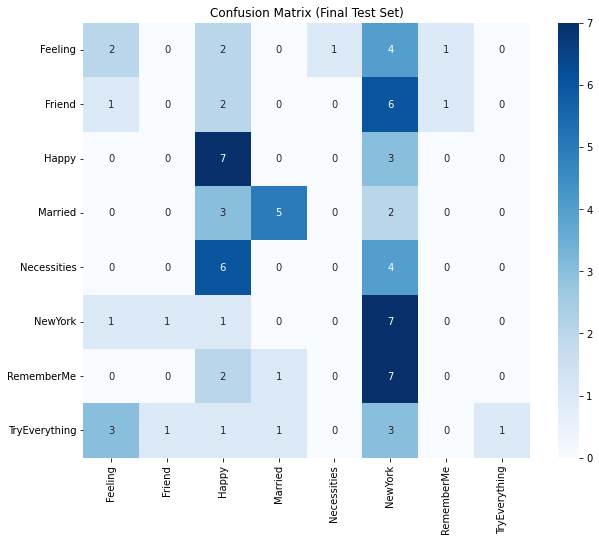

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf

def print_performance_summary(y_true, y_pred, target_names):
    # Calculate metrics (using macro average to balance classes)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    dash_line = "-" * 80
    equal_line = "=" * 80
    
    print(dash_line)
    print("TEST SET PERFORMANCE SUMMARY".center(80))
    print(dash_line)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} F1-Score:  {f1:.4f}") 
    print(dash_line)
    print(equal_line)
    print(equal_line)
    
    # Print detailed Classification Report
    print(classification_report(y_true, y_pred, target_names=target_names))


# Execution of Final Test
print("\n Final Test Evaluation...")

model = build_standard_cnn((CONFIG["IMG_SIZE"][0], CONFIG["IMG_SIZE"][1], 3), num_classes)
model.load_weights(best_model_path) 

# Generate Predictions
print("Predicting on Test Set...")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


print_performance_summary(y_test, y_pred, target_names=unique_songs)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_songs, yticklabels=unique_songs)
plt.title('Confusion Matrix (Final Test Set)')
plt.show()

In [14]:
from sklearn.metrics import f1_score
import math
import random


# Configuration for SA
SA_CONFIG = {
    "MAX_ITER": 15,       # Maximum number of iterations
    "INITIAL_TEMP": 0.1,  # Initial temperature
    "COOLING_RATE": 0.80, # Cooling rate
    "EPOCHS_SEARCH": 15,  
    "PATIENCE": 3         #  for faster early stopping
}

SEARCH_SPACE = {
    'n_conv_layers': [3, 4, 5],
    'base_filters': [16, 32, 64],
    'n_dense_layers': [0, 1], 
    'dense_units': [128, 256],
    'dropout': [0.2, 0.3, 0.5],
    'lr': [1e-3, 5e-4, 1e-4] 
}


def build_dynamic_cnn(config):
    inp = layers.Input(shape=(256, 256, 3))
    x = inp
    
    # Dynamic Convolutional Layers
    filters = config['base_filters']
    for i in range(config['n_conv_layers']):
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        # Use simple MaxPooling for the search phase to save compute
        x = layers.MaxPooling2D()(x) 
        filters *= 2
        
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(config['dropout'])(x)
    
    # Dynamic Dense Layers
    for _ in range(config['n_dense_layers']):
        x = layers.Dense(config['dense_units'], activation='relu')(x)
        x = layers.Dropout(config['dropout'])(x)
        
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

def get_random_neighbor(current_config):
    new_config = current_config.copy()
    param_to_change = random.choice(list(SEARCH_SPACE.keys()))
    possible_values = SEARCH_SPACE[param_to_change]
    current_val = new_config[param_to_change]
    
    # Select a different value
    candidates = [v for v in possible_values if v != current_val]
    if not candidates: return current_config, param_to_change # Handle single-option case
    
    new_val = random.choice(candidates)
    new_config[param_to_change] = new_val
    return new_config, param_to_change

def evaluate_config_f1(config):
    """
    Runs 5-Fold CV and returns the average Macro F1-Score.
    Uses dev_data_cache from the previous CNN step.
    """
    scores = []
    
    # We use the StratifiedKFold logic again on the cached data indices
    skf_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=2025)
    # Dummy labels just for splitting logic
    dummy_labels = [item['label'] for item in dev_data_cache]
    
    for train_idx, val_idx in skf_search.split(dummy_labels, dummy_labels):
        # Data Preparation (Reusing dev_data_cache)
        X_train_fold = []
        y_train_fold = []
        for i in train_idx:
            item = dev_data_cache[i]
            X_train_fold.extend(item['train'])
            y_train_fold.extend([item['label']] * 6)
            
        X_val_fold = []
        y_val_fold = []
        for i in val_idx:
            item = dev_data_cache[i]
            X_val_fold.append(item['val'])
            y_val_fold.append(item['label'])
            
        X_train_fold = np.array(X_train_fold)
        y_train_fold = np.array(y_train_fold)
        X_val_fold = np.array(X_val_fold)
        y_val_fold = np.array(y_val_fold)
        
        # Model Training
        tf.keras.backend.clear_session()
        model = build_dynamic_cnn(config)
        model.compile(optimizer=optimizers.Adam(learning_rate=config['lr']),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        # Reduced patience for speed
        es = callbacks.EarlyStopping(monitor='val_accuracy', patience=SA_CONFIG["PATIENCE"], 
                                     restore_best_weights=True)
        
        model.fit(X_train_fold, y_train_fold, 
                  validation_data=(X_val_fold, y_val_fold),
                  epochs=SA_CONFIG["EPOCHS_SEARCH"], 
                  batch_size=32,
                  callbacks=[es], verbose=0)
        
        # Calculate F1 Score
        y_pred_probs = model.predict(X_val_fold, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        f1 = f1_score(y_val_fold, y_pred, average='macro', zero_division=0)
        
        scores.append(f1)
        del model
        gc.collect()
        
    return np.mean(scores)


# Initialization
current_config = {k: random.choice(v) for k, v in SEARCH_SPACE.items()}
current_score = evaluate_config_f1(current_config)

best_config = current_config.copy()
best_score = current_score
temperature = SA_CONFIG["INITIAL_TEMP"]

print(f"Initial F1: {current_score:.4f} | Config: {current_config}")

for i in range(SA_CONFIG["MAX_ITER"]):
    neighbor_config, changed_param = get_random_neighbor(current_config)
    
    print(f"\n--- Iter {i+1}/{SA_CONFIG['MAX_ITER']} (Temp={temperature:.4f}) ---")
    print(f"Testing change: {changed_param} -> {neighbor_config[changed_param]}")
    
    neighbor_score = evaluate_config_f1(neighbor_config)
    
    # Evaluation (Maximize F1)
    delta_score = neighbor_score - current_score
    is_accepted = False
    
    if delta_score > 0:
        is_accepted = True
        msg = "Better (Accepted)"
    else:
        # Metropolis Criterion
        prob = math.exp(delta_score / temperature)
        if random.random() < prob:
            is_accepted = True
            msg = f"Worse but Accepted (Prob={prob:.2f})"
        else:
            is_accepted = False
            msg = f"Worse and Rejected (Prob={prob:.2f})"
            
    print(f"Result F1: {neighbor_score:.4f} (Current: {current_score:.4f}) -> {msg}")
    
    if is_accepted:
        current_config = neighbor_config
        current_score = neighbor_score
        
        if current_score > best_score:
            best_score = current_score
            best_config = current_config.copy()
            print(f"NEW BEST FOUND! F1: {best_score:.4f}")
            
    temperature *= SA_CONFIG["COOLING_RATE"]

Initial F1: 0.1424 | Config: {'n_conv_layers': 3, 'base_filters': 16, 'n_dense_layers': 1, 'dense_units': 256, 'dropout': 0.2, 'lr': 0.001}

--- Iter 1/15 (Temp=0.1000) ---
Testing change: dropout -> 0.3
Result F1: 0.0878 (Current: 0.1424) -> Worse and Rejected (Prob=0.58)

--- Iter 2/15 (Temp=0.0800) ---
Testing change: n_conv_layers -> 4
Result F1: 0.1672 (Current: 0.1424) -> Better (Accepted)
NEW BEST FOUND! F1: 0.1672

--- Iter 3/15 (Temp=0.0640) ---
Testing change: base_filters -> 32
Result F1: 0.2668 (Current: 0.1672) -> Better (Accepted)
NEW BEST FOUND! F1: 0.2668

--- Iter 4/15 (Temp=0.0512) ---
Testing change: dense_units -> 128
Result F1: 0.1704 (Current: 0.2668) -> Worse and Rejected (Prob=0.15)

--- Iter 5/15 (Temp=0.0410) ---
Testing change: base_filters -> 64
Result F1: 0.1970 (Current: 0.2668) -> Worse and Rejected (Prob=0.18)

--- Iter 6/15 (Temp=0.0328) ---
Testing change: lr -> 0.0001
Result F1: 0.1427 (Current: 0.2668) -> Worse and Rejected (Prob=0.02)

--- Iter 7/15

In [15]:
# the code to store the model is included in this cell
# Retraining on Full Dev Set

print(f"Final Best Config (F1={best_score:.4f}):")
print(best_config)
print("="*50)

print("Preparing Full Training Data...")

X_train_full = []
y_train_full = []

for item in dev_data_cache:
    X_train_full.extend(item['train'])       # All 6 augmented crops
    y_train_full.extend([item['label']] * 6) # Labels

X_train_full = np.array(X_train_full)
y_train_full = np.array(y_train_full)

# Shuffle
idx = np.random.permutation(len(X_train_full))
X_train_full = X_train_full[idx]
y_train_full = y_train_full[idx]

print(f"Full Train Shape: {X_train_full.shape}")

# Build Model
tf.keras.backend.clear_session()
final_model = build_dynamic_cnn(best_config)
final_model.compile(optimizer=optimizers.Adam(learning_rate=best_config['lr']),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])


checkpoint = callbacks.ModelCheckpoint("best_sa_cnn_final.h5", monitor='val_accuracy', 
                                     save_best_only=True, verbose=1)
es = callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

print("Retraining...")
history = final_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_test, y_test), 
    epochs=50, # Final training uses more epochs
    batch_size=32,
    callbacks=[checkpoint, es],
    verbose=1
)

Final Best Config (F1=0.3170):
{'n_conv_layers': 5, 'base_filters': 32, 'n_dense_layers': 1, 'dense_units': 256, 'dropout': 0.2, 'lr': 0.001}
Preparing Full Training Data...
Full Train Shape: (4320, 256, 256, 3)
Retraining...
Epoch 1/50
134/135 [============================>.] - ETA: 0s - loss: 2.0890 - accuracy: 0.1751
Epoch 1: val_accuracy improved from -inf to 0.12500, saving model to best_sa_cnn_final.h5
135/135 [==============================] - 6s 38ms/step - loss: 2.0883 - accuracy: 0.1752 - val_loss: 2.7965 - val_accuracy: 0.1250
Epoch 2/50
135/135 [==============================] - ETA: 0s - loss: 1.7493 - accuracy: 0.3363
Epoch 2: val_accuracy improved from 0.12500 to 0.16250, saving model to best_sa_cnn_final.h5
135/135 [==============================] - 4s 32ms/step - loss: 1.7493 - accuracy: 0.3363 - val_loss: 2.4940 - val_accuracy: 0.1625
Epoch 3/50
135/135 [==============================] - ETA: 0s - loss: 1.3943 - accuracy: 0.4803
Epoch 3: val_accuracy did not improve f


Final Evaluation on Test Set...
3/3 [==============================] - 0s 9ms/step
--------------------------------------------------------------------------------
                          TEST SET PERFORMANCE SUMMARY                          
--------------------------------------------------------------------------------
Accuracy:  0.4750
Precision: 0.5422 F1-Score:  0.4327
--------------------------------------------------------------------------------
               precision    recall  f1-score   support

      Feeling       0.33      0.30      0.32        10
       Friend       0.70      0.70      0.70        10
        Happy       0.60      0.60      0.60        10
      Married       0.47      0.90      0.62        10
  Necessities       0.23      0.30      0.26        10
      NewYork       0.50      0.80      0.62        10
   RememberMe       0.50      0.10      0.17        10
TryEverything       1.00      0.10      0.18        10

     accuracy                           0

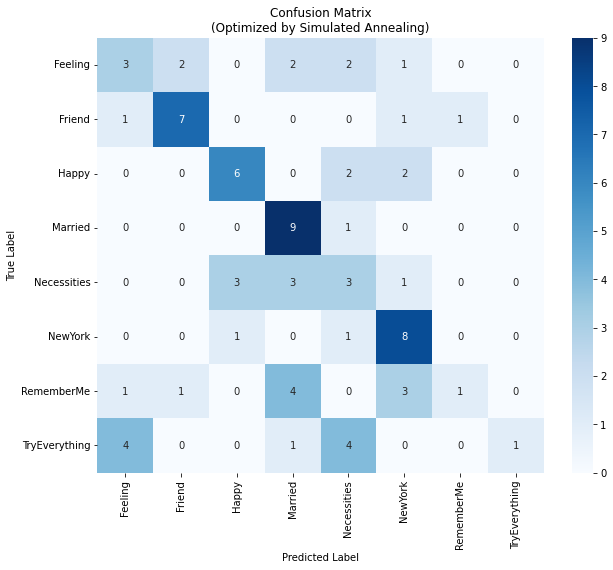

In [16]:

# Final Evaluation
print("\nFinal Evaluation on Test Set...")

# Load best weights
final_model.load_weights("best_sa_cnn_final.h5")

# Predict
y_pred_probs = final_model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


try:
    print_performance_summary(y_test, y_pred, target_names=unique_songs)
except NameError:
    # Fallback if function is not defined
    from sklearn.metrics import accuracy_score, precision_score, f1_score
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=unique_songs))

# 2. Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_songs, yticklabels=unique_songs)
plt.title('Confusion Matrix\n(Optimized by Simulated Annealing)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**the cell below give an example of use of the cnn model to predict the label**

In [40]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models
TARGET_FILE = 'MLEndHWII_sample_800/S1_whistle_2_Friend.wav'
BEST_CONFIG = best_config

# Global Settings
SETTINGS = {
    "SR": 22050,
    "DURATION": 10.0,
    "IMG_SIZE": (256, 256),
    "WEIGHTS_FILE": "best_sa_cnn_final.h5"#the parameter I stored in my local
}

CLASSES =unique_songs
SETTINGS["NUM_CLASSES"] = len(CLASSES)

def build_model_from_config(config):
    inp = layers.Input(shape=(SETTINGS["IMG_SIZE"][0], SETTINGS["IMG_SIZE"][1], 3))
    x = inp
    
    # Convolutional Layers
    filters = config['base_filters']
    for i in range(config['n_conv_layers']):
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
        filters *= 2
        
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(config['dropout'])(x)
    
    # Dense Layers
    for _ in range(config['n_dense_layers']):
        x = layers.Dense(config['dense_units'], activation='relu')(x)
        x = layers.Dropout(config['dropout'])(x)
        
    out = layers.Dense(SETTINGS["NUM_CLASSES"], activation='softmax')(x)
    return models.Model(inp, out)

def preprocess_audio(file_path):
    # Load Audio
    y, _ = librosa.load(file_path, sr=SETTINGS["SR"])
    
    # 2. Pad or Trim to 10 seconds
    target_len = int(SETTINGS["SR"] * SETTINGS["DURATION"])
    if len(y) < target_len:
        repeats = target_len // len(y) + 1
        y = np.tile(y, repeats)[:target_len]
    else:
        y = y[:target_len]
        
    # CQT Transform
    cqt = np.abs(librosa.cqt(y, sr=SETTINGS["SR"], n_bins=84, bins_per_octave=12, hop_length=512))
    cqt_db = librosa.amplitude_to_db(cqt, ref=np.max)
    
    min_v, max_v = cqt_db.min(), cqt_db.max()
    cqt_norm = (cqt_db - min_v) / (max_v - min_v + 1e-6)
    

    img = cqt_norm[..., np.newaxis]
    img = tf.image.resize(img, SETTINGS["IMG_SIZE"])
    img = tf.image.grayscale_to_rgb(img)
    
    img = tf.expand_dims(img, axis=0) 
    return img

if __name__ == "__main__":
    
    print(f"Processing audio: {TARGET_FILE}")
    input_tensor = preprocess_audio(TARGET_FILE)
    
    probs = model.predict(input_tensor, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = CLASSES[pred_idx]
    confidence = probs[pred_idx] * 100
    
    print("="*40)
    print(f"Predicted Class: {pred_label}")
    print(f"Confidence:      {confidence:.4f}%")
    print("="*40)
    
    print("Probabilities per class:")
    for i, p in enumerate(probs):
        print(f"{CLASSES[i]}: {p:.6f}")

Processing audio: MLEndHWII_sample_800/S1_whistle_2_Friend.wav
Predicted Class: Friend
Confidence:      99.0052%
Probabilities per class:
Feeling: 0.000015
Friend: 0.990052
Happy: 0.000008
Married: 0.000553
Necessities: 0.000543
NewYork: 0.008829
RememberMe: 0.000001
TryEverything: 0.000000


### ensamble machinic learning and deep learning

In [ ]:
I find SVM perform good in detecting the catagory of a song

=== Extracting TRAINING features ===
Song label mapping: {'Feeling': 0, 'Friend': 1, 'Happy': 2, 'Married': 3, 'Necessities': 4, 'NewYork': 5, 'RememberMe': 6, 'TryEverything': 7}
Extracting features for 720 samples...


Feature extraction: 100%|██████████| 720/720 [02:36<00:00,  4.61it/s]



Feature extraction finished!
Successful samples: 720
Failed samples: 0
Feature matrix shape: (720, 26)
Label distribution: [90 90 90 90 90 90 90 90]
=== Extracting TESTING features ===
Song label mapping: {'Feeling': 0, 'Friend': 1, 'Happy': 2, 'Married': 3, 'Necessities': 4, 'NewYork': 5, 'RememberMe': 6, 'TryEverything': 7}
Extracting features for 80 samples...


Feature extraction: 100%|██████████| 80/80 [00:16<00:00,  4.74it/s]


Feature extraction finished!
Successful samples: 80
Failed samples: 0
Feature matrix shape: (80, 26)
Label distribution: [10 10 10 10 10 10 10 10]

Training Shape: (720, 26)
Testing Shape:  (80, 26)
Train Class Dist: Hum=438, Whistle=282
Training SVM model (Binary: Hum vs Whistle)...
Training complete.

=== SVM Accuracy (Hum vs Whistle): 96.25% ===

              precision    recall  f1-score   support

         Hum       0.98      0.96      0.97        49
     Whistle       0.94      0.97      0.95        31

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



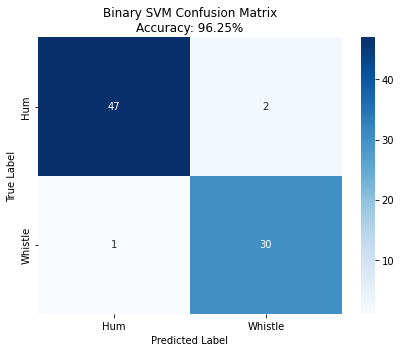

In [14]:


def extract_binary_features(df, source_name=""):

    print(f"=== Extracting {source_name} features ===")
    
    X_raw, _, _, _, failed = extract_dataset_features(
        df, 
        max_samples=None, 
        pitch_method='librosa', 
        target_sr=22050
    )
    
    y_binary = []
    
    valid_df = df[~df['file_path'].isin(failed)]
    
    for _, row in valid_df.iterrows():
        fname = str(row['file_path']).lower()
        if "whistle" in fname:
            y_binary.append(1) # Whistle
        else:
            y_binary.append(0) # Hum
            
    return X_raw, np.array(y_binary)


X_train_raw, y_train = extract_binary_features(train_df, "TRAINING")
X_test_raw, y_test = extract_binary_features(test_df, "TESTING")

print(f"\nTraining Shape: {X_train_raw.shape}")
print(f"Testing Shape:  {X_test_raw.shape}")
print(f"Train Class Dist: Hum={np.sum(y_train==0)}, Whistle={np.sum(y_train==1)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)


svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=2025)

print("Training SVM model (Binary: Hum vs Whistle)...")
svm_model.fit(X_train_scaled, y_train)
print("Training complete.")


y_pred = svm_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"\n=== SVM Accuracy (Hum vs Whistle): {acc:.2%} ===\n")

target_names = ['Hum', 'Whistle']
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Binary SVM Confusion Matrix\nAccuracy: {acc:.2%}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [25]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

data_path = 'MLEndHWII_sample_800/*.wav'
files = sorted(glob.glob(data_path))

rows = []
for f in files:
    name = os.path.basename(f)
    parts = name.split("_")
    

    if len(parts) >= 4:
        song = parts[3].split(".")[0] 
        fname_lower = name.lower()
        
        if "whistle" in fname_lower:
            m_type = 1 
        else:
            m_type = 0 
            
        rows.append([f, song, m_type])

df = pd.DataFrame(rows, columns=["path", "song", "label"])

counts = df['song'].value_counts()
df = df[df['song'].isin(counts[counts > 5].index)].reset_index(drop=True)

unique_songs = sorted(df.song.unique())
song_map = {s: i for i, s in enumerate(unique_songs)}
df["song_label"] = df["song"].map(song_map)
NUM_SONGS = len(unique_songs)

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=2025)
train_idx, test_idx = next(splitter.split(df, df["song_label"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

hum_df = train_df[train_df['label'] == 0].reset_index(drop=True)

whistle_df = train_df[train_df['label'] == 1].reset_index(drop=True)


In [29]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications.efficientnet import preprocess_input 
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm import tqdm
import gc


EXPERT_MODEL_CONFIG = {
    'n_conv_layers': 5, 
    'base_filters': 32, 
    'n_dense_layers': 1, 
    'dense_units': 256, 
    'dropout': 0.2, 
    'lr': 0.001 
}
CONFIG = {
    "SR": 22050, "DURATION": 10.0, "IMG_SIZE": (256, 256),
    "BATCH_SIZE": 32, "EPOCHS": 25, 
    "N_VARIANTS": 6,   
    "VAL_SPLIT": 0.2   
}
GLOBAL_WEIGHTS_PATH = "best_sa_cnn_final.h5" 


all_songs = set(hum_df['song_label'].unique()) | set(whistle_df['song_label'].unique())
NUM_SONGS = len(all_songs)
def extract_feature_special(path, mode='train'):
    try:
        y, _ = librosa.load(path, sr=CONFIG["SR"])
        target_len = int(CONFIG["SR"] * CONFIG["DURATION"])
        current_len = len(y)
        if current_len < target_len:
            repeats = target_len // current_len + 1
            y = np.tile(y, repeats)[:target_len]
        elif current_len > target_len:
            if mode == 'train':
                max_start = current_len - target_len
                start = np.random.randint(0, max_start)
                y = y[start : start + target_len]
            else:
                y = y[:target_len]
        cqt = np.abs(librosa.cqt(y, sr=CONFIG["SR"], n_bins=84, bins_per_octave=12, hop_length=512))
        cqt_db = librosa.amplitude_to_db(cqt, ref=np.max)
        min_v, max_v = cqt_db.min(), cqt_db.max()
        cqt_norm = (cqt_db - min_v) / (max_v - min_v + 1e-6)
        
        img = cqt_norm[..., np.newaxis]
        img = tf.image.resize(img, CONFIG["IMG_SIZE"]) 
        img = tf.image.grayscale_to_rgb(img) 
        
        img = img * 255.0
        img = preprocess_input(img)
        return img.numpy()
    except:
        return np.zeros((CONFIG["IMG_SIZE"][0], CONFIG["IMG_SIZE"][1], 3))

def build_custom_expert_model(input_shape, num_classes, config):
    inp = layers.Input(shape=input_shape)
    x = inp
    filters = config['base_filters']
    
    for i in range(config['n_conv_layers']):
        x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        
        if i < 3: 
            x = layers.MaxPooling2D((2, 2))(x)
            
        filters = min(filters * 2, 512)
        
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(config['dropout'])(x)
    
    for _ in range(config['n_dense_layers']):
        x = layers.Dense(config['dense_units'], activation='relu')(x)
        x = layers.Dropout(config['dropout'])(x)
        
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

def finetune_expert_from_pretrained(subset_df, expert_name, pretrained_path):
    print(f"\n" + "="*60)
    print(f"FINE-TUNING: {expert_name} | Samples: {len(subset_df)}")
    print(f"Loading weights from: {pretrained_path}")
    print("="*60)
    
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=CONFIG["VAL_SPLIT"], random_state=2025)
    tr_idx, val_idx = next(splitter.split(subset_df, subset_df['song_label']))
    X_tr, y_tr = [], []
    for i in tqdm(tr_idx, desc="Train"):
        row = subset_df.iloc[i]
        for _ in range(CONFIG["N_VARIANTS"]): 
            X_tr.append(extract_feature_special(row.path, mode='train'))
            y_tr.append(row.song_label)
            
    X_v, y_v = [], []
    for i in tqdm(val_idx, desc="Val"):
        row = subset_df.iloc[i]
        X_v.append(extract_feature_special(row.path, mode='val'))
        y_v.append(row.song_label)
        
    X_tr = np.array(X_tr); y_tr = tf.keras.utils.to_categorical(y_tr, NUM_SONGS)
    X_v = np.array(X_v); y_v = tf.keras.utils.to_categorical(y_v, NUM_SONGS)
    
    tf.keras.backend.clear_session()
    model = build_custom_expert_model(CONFIG["IMG_SIZE"]+(3,), NUM_SONGS, EXPERT_MODEL_CONFIG)
    model.load_weights(pretrained_path) 

    print("Starting Fine-tuning (LR=1e-4)...")
    model.compile(optimizer=optimizers.Adam(1e-4), 
                  loss='categorical_crossentropy', metrics=['accuracy'])
    
    save_path = f"best_finetuned_{expert_name}.h5"
    
    history = model.fit(
        X_tr, y_tr, 
        validation_data=(X_v, y_v),
        epochs=CONFIG["EPOCHS"], 
        batch_size=CONFIG["BATCH_SIZE"], 
        verbose=1,
        callbacks=[
            callbacks.ModelCheckpoint(save_path, save_best_only=True, monitor='val_accuracy', verbose=1),
            callbacks.EarlyStopping(patience=6, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
        ]
    )
    
    best_val_acc = max(history.history['val_accuracy'])
    print(f"\n>>> {expert_name} Best Validation Accuracy: {best_val_acc*100:.2f}%")
    
    del X_tr, X_v, y_tr, y_v
    gc.collect()
    return save_path


hum_model_path = finetune_expert_from_pretrained(hum_df, "Hum_Expert", GLOBAL_WEIGHTS_PATH)
whistle_model_path = finetune_expert_from_pretrained(whistle_df, "Whistle_Expert", GLOBAL_WEIGHTS_PATH)

print(f"\n" + "="*60)
print(f"Hum Expert Model:     {hum_model_path}")
print(f"Whistle Expert Model: {whistle_model_path}")

Total Songs (Classes): 8

FINE-TUNING: Hum_Expert | Samples: 441
Loading weights from: best_sa_cnn_final.h5
Caching Augmented Data...


Val: 100%|██████████| 89/89 [00:03<00:00, 25.03it/s]


>>> Pretrained weights loaded successfully.
Starting Fine-tuning (LR=1e-4)...
Epoch 1/25
65/66 [============================>.] - ETA: 0s - loss: 0.0956 - accuracy: 0.9880
Epoch 1: val_accuracy improved from -inf to 0.58427, saving model to best_finetuned_Hum_Expert.h5
66/66 [==============================] - 5s 41ms/step - loss: 0.0946 - accuracy: 0.9882 - val_loss: 1.4094 - val_accuracy: 0.5843 - lr: 1.0000e-04
Epoch 2/25
65/66 [============================>.] - ETA: 0s - loss: 0.0497 - accuracy: 0.9937
Epoch 2: val_accuracy improved from 0.58427 to 0.85393, saving model to best_finetuned_Hum_Expert.h5
66/66 [==============================] - 2s 36ms/step - loss: 0.0491 - accuracy: 0.9938 - val_loss: 0.3961 - val_accuracy: 0.8539 - lr: 1.0000e-04
Epoch 3/25
65/66 [============================>.] - ETA: 0s - loss: 0.0364 - accuracy: 0.9952
Epoch 3: val_accuracy improved from 0.85393 to 0.95506, saving model to best_finetuned_Hum_Expert.h5
66/66 [==============================] - 2s 35

Val: 100%|██████████| 56/56 [00:02<00:00, 25.84it/s]


>>> Pretrained weights loaded successfully.
Starting Fine-tuning (LR=1e-4)...
Epoch 1/25
42/42 [==============================] - ETA: 0s - loss: 0.1573 - accuracy: 0.9776
Epoch 1: val_accuracy improved from -inf to 0.33929, saving model to best_finetuned_Whistle_Expert.h5
42/42 [==============================] - 4s 50ms/step - loss: 0.1573 - accuracy: 0.9776 - val_loss: 3.0074 - val_accuracy: 0.3393 - lr: 1.0000e-04
Epoch 2/25
41/42 [============================>.] - ETA: 0s - loss: 0.0930 - accuracy: 0.9909
Epoch 2: val_accuracy improved from 0.33929 to 0.66071, saving model to best_finetuned_Whistle_Expert.h5
42/42 [==============================] - 2s 39ms/step - loss: 0.0929 - accuracy: 0.9910 - val_loss: 1.0446 - val_accuracy: 0.6607 - lr: 1.0000e-04
Epoch 3/25
41/42 [============================>.] - ETA: 0s - loss: 0.0594 - accuracy: 0.9970
Epoch 3: val_accuracy improved from 0.66071 to 0.91071, saving model to best_finetuned_Whistle_Expert.h5
42/42 [===========================

In [35]:
test_df['file_path'] = test_df['path']

Song label mapping: {'Feeling': 0, 'Friend': 1, 'Happy': 2, 'Married': 3, 'Necessities': 4, 'NewYork': 5, 'RememberMe': 6, 'TryEverything': 7}
Extracting features for 80 samples...


Feature extraction: 100%|██████████| 80/80 [00:17<00:00,  4.67it/s]



Feature extraction finished!
Successful samples: 80
Failed samples: 0
Feature matrix shape: (80, 26)
Label distribution: [10 10 10 10 10 10 10 10]


100%|██████████| 80/80 [00:03<00:00, 24.73it/s]



FINAL SYSTEM EVALUATION REPORT
Gatekeeper (SVM) Accuracy: 98.75%
Accuracy:0.5250
Precision:0.5546 F1-Score:0.5284

Detailed Classification Report:
               precision    recall  f1-score   support

      Feeling       0.57      0.40      0.47        10
       Friend       0.56      0.50      0.53        10
        Happy       1.00      0.60      0.75        10
      Married       0.64      0.70      0.67        10
  Necessities       0.42      0.50      0.45        10
      NewYork       0.62      0.80      0.70        10
   RememberMe       0.31      0.40      0.35        10
TryEverything       0.33      0.30      0.32        10

     accuracy                           0.53        80
    macro avg       0.55      0.52      0.53        80
 weighted avg       0.55      0.53      0.53        80



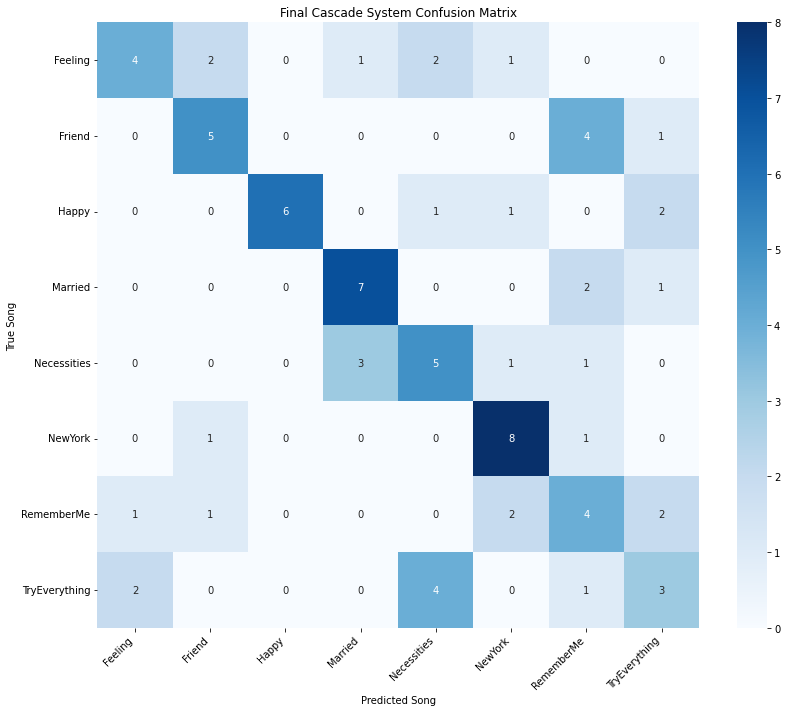

In [50]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix
X_test_svm_raw, _, _, _, _ = extract_dataset_features(
    test_df, 
    max_samples=None, 
    pitch_method='librosa', 
    target_sr=CONFIG["SR"]
)

X_test_svm = scaler.transform(X_test_svm_raw)
X_test_cqt = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img = extract_feature_special(row.path, mode='val')
    X_test_cqt.append(img)
X_test_cqt = np.array(X_test_cqt)

y_test_true_song = test_df['song_label'].values
y_test_true_type = test_df['label'].values # 0: Hum, 1: Whistle
hum_model = models.load_model(hum_model_path)
whistle_model = models.load_model(whistle_model_path)
final_predictions = []
routing_stats = {"Sent_to_Hum": 0, "Sent_to_Whistle": 0}
gatekeeper_correct = 0

for i in range(len(test_df)):
    svm_input = X_test_svm[i:i+1]
    pred_type = svm_model.predict(svm_input)[0]
    
    if pred_type == y_test_true_type[i]:
        gatekeeper_correct += 1
    
    cnn_input = X_test_cqt[i:i+1]
    
    if pred_type == 0:
        probs = hum_model.predict(cnn_input, verbose=0)
        routing_stats["Sent_to_Hum"] += 1
    else:
        probs = whistle_model.predict(cnn_input, verbose=0)
        routing_stats["Sent_to_Whistle"] += 1
        
    pred_song = np.argmax(probs)
    final_predictions.append(pred_song)

final_predictions = np.array(final_predictions)

print("\n" + "="*60)
print("FINAL SYSTEM EVALUATION REPORT")
print("="*60)

svm_acc = gatekeeper_correct / len(test_df)
print(f"Gatekeeper (SVM) Accuracy: {svm_acc*100:.2f}%")
acc = accuracy_score(y_test_true_song, final_predictions)
prec = precision_score(y_test_true_song, final_predictions, average='macro', zero_division=0)
f1 = f1_score(y_test_true_song, final_predictions, average='macro')

print(f"Accuracy:{acc:.4f}")
print(f"Precision:{prec:.4f} F1-Score:{f1:.4f}")
print("=" * 80)
print("=" * 80)
unique_songs = sorted(test_df['song'].unique())
print("\nDetailed Classification Report:")
print(classification_report(y_test_true_song, final_predictions, target_names=unique_songs))
cm = confusion_matrix(y_test_true_song, final_predictions)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_songs, yticklabels=unique_songs)
plt.title(f'Final Cascade System Confusion Matrix')
plt.xlabel('Predicted Song')
plt.ylabel('True Song')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [41]:
import numpy as np
import pandas as pd
import librosa
import os

def predict_new_audio(file_path, true_label=None):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    print(f"\nProcessing audio: {file_path}")
    features, _ = extract_audio_features(
        file_path, 
        sr=CONFIG["SR"], 
        scale_audio=True, 
        pitch_method='librosa'
    )

    if features.ndim == 1:
        X_raw = features.reshape(1, -1)
    else:
        X_raw = features
    
    # Normalize features
    X_svm = scaler.transform(X_raw)
    pred_type_idx = svm_model.predict(X_svm)[0]
    pred_type_str = "Whistle" if pred_type_idx == 1 else "Hum"
    print(f"Gatekeeper Prediction: {pred_type_str}")

    cqt_img = extract_feature_special(file_path, mode='val')
    
    # Add batch dimension
    cnn_input = cqt_img[np.newaxis, ...]
    # Route to appropriate expert
    if pred_type_idx == 0:
        probs = hum_model.predict(cnn_input, verbose=0)[0]
        expert_name = "Hum_Expert"
    else:
        probs = whistle_model.predict(cnn_input, verbose=0)[0]
        expert_name = "Whistle_Expert"
        
    # Get predicted song class
    pred_song_idx = np.argmax(probs)
    confidence = probs[pred_song_idx] * 100
    
    # Decode song name
    unique_songs = sorted(test_df['song'].unique())
    pred_song_name = unique_songs[pred_song_idx]

    # Output results
    print(f"Predicted Class: {pred_song_name}")
    print(f"Confidence:      {confidence:.5f}%")
    
    print("Probabilities:")
    top3_idx = np.argsort(probs)[::-1]
    for idx in top3_idx:
        print(f"{unique_songs[idx]:>15}: {probs[idx]:.6f}")
        

# Example usage
TARGET_FILE = 'MLEndHWII_sample_800/S1_whistle_2_Friend.wav' 
predict_new_audio(TARGET_FILE, true_label="Friend")


Processing audio: MLEndHWII_sample_800/S1_whistle_2_Friend.wav
Gatekeeper Prediction: Whistle
Predicted Class: Friend
Confidence:      98.78168%
Probabilities:
         Friend: 0.987817
    Necessities: 0.004755
     RememberMe: 0.003007
        NewYork: 0.002717
        Feeling: 0.000882
        Married: 0.000734
          Happy: 0.000087
  TryEverything: 0.000001


# 7 Conclusions

# 8 Reference：

1 PMLBook.github.io (URL: `https://PMLBook.github.io`). (I learned basic concepts and model knowledge from this book)

2 Stanford Fei-Fei Li's "CS231N Computer Vision" Course Lec2 "Image Classification pipeline". (My 5-fold cross-validation referenced its architecture)

3 Taqiyaehsan, S., et al. Domestic Audio Classification (URL: `https://taqiyaehsan.github.io/docs/Domestic%20Audio%20Classification.pdf`). (The use of MFCC in audio detecting task, CNN is noted in this essay that it can be used in audio detecting)

4 Scikit-learn Documentation. Voting Classifier (URL: `https://scikit-learn.org/stable/modules/ensemble.html#voting-classifier`). (voting)

5 Scikit-learn Documentation. Stacking Classifier (URL: `https://scikit-learn.org/stable/modules/ensemble.html#stacking`). (how to use stacking in ensemble)

6 jmerkt/rt-cqt (GitHub Repository: `https://github.com/jmerkt/rt-cqt`). (learn CQT)

7 Zhihu Column "How to Understand CNN" (URL: `https://zhuanlan.zhihu.com/p/561991816`). (learn CNN)

8 Spotintelligence. Simulated Annealing Made Simple (URL: `https://spotintelligence.com/2025/10/22/simulated-annealing-made-simple-how-to-tutorial-in-python/`). (simulated annealing)

9 Santhosh Hari. Hyperparameter Tuning using Simulated Annealing (URL: `https://santhoshhari.github.io/simulated_annealing/`). (how to tune the pararmeter in the SA process)



 